In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from datetime import datetime as dt
from datetime import timedelta as td
from scipy.stats import norm, kstest, chi2, f
from matplotlib import cm, colors
from scipy.optimize import least_squares
from matplotlib.colors import LinearSegmentedColormap
from sklearn.neighbors import KernelDensity
import sys
from pathlib import Path
import os

plt.rcParams['figure.figsize'] = (16,9)

In [3]:
os.chdir(sys.path[0])
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
os.chdir(sys.path[-1])

In [4]:
from src.data import *

## Data Download

In [6]:
memes = ['PEPE', 'MOG', 'FARTCOIN', 'SPX', 'GIGA', 'POPCAT', 'BONK', 'WIF', 'TOSHI', 'BRETT', 'FLOKI', 'FWOG', 'HARRYP']
start_date_old, end_date_old = dt(2025, 1, 22, 13), dt(2025, 8, 16, 2)

### Binance

In [7]:
memes_bin = {'MOG': '1000000MOGUSDT', 'BONK': '1000BONKUSDC', 'FLOKI': '1000FLOKIUSDT', 'PEPE': '1000PEPEUSDC', 'BRETT': 'BRETTUSDT', 'FARTCOIN': 'FARTCOINUSDT', 'POPCAT': 'POPCATUSDT', 'SPX': 'SPXUSDT', 'WIF': 'WIFUSDC'}

#### Klines

Hours

In [9]:
%%time
for m in memes_bin.keys():
    globals()["df_" + m + "_bin"] = klines_bin(memes_bin[m], start_date_old, end_date_old, 'h')

CPU times: total: 875 ms
Wall time: 1min 33s


Minutes

In [10]:
%%time
for m in memes_bin.keys():
    globals()["df_" + m + "_bin_min"] = klines_bin(memes_bin[m], start_date_old, end_date_old, 'm')

CPU times: total: 9.08 s
Wall time: 3min 28s


#### Market impact data

In [ ]:
%%time
ag_tr_df = pd.DataFrame()
for m in memes_bin.keys():
    print(m, dt.now())
    ag_tr_m = pd.DataFrame()
    for i in range(start_date_old.month, end_date_old.month + 1):
        print(i, dt.now())
        str_i = f"{i:0{2}d}"
        ag_tr_m_i = pd.read_csv("https://data.binance.vision/data/futures/um/monthly/aggTrades/" + memes_bin[m] + "/" + memes_bin[m] + "-aggTrades-2025-0" + str_i + ".zip")
        egreg = ag_tr_m_i[['transact_time', 'is_buyer_maker', 'quantity']].groupby(['transact_time', 'is_buyer_maker'], as_index = False).count()
        ag_tr_m_i = ag_tr_m_i.merge(egreg.loc[egreg['quantity'] > 1][['transact_time', 'is_buyer_maker']], how = "right", on = ["transact_time", "is_buyer_maker"])
        del egreg
        ag_tr_m_i['volume'] = ag_tr_m_i['price'] * ag_tr_m_i['quantity']
        ag_tr_m_i = ag_tr_m_i.groupby(['transact_time', 'is_buyer_maker'], as_index = False).apply(lambda x: x['volume'].sum() / x['quantity'].sum() / x['price'].iloc[0] - 1, include_groups = False).merge(ag_tr_m_i[['transact_time', 'is_buyer_maker', 'volume']].groupby(['transact_time', 'is_buyer_maker'], as_index = False).sum(), on = ['transact_time', 'is_buyer_maker'])
        ag_tr_m = pd.concat([ag_tr_m, ag_tr_m_i])
    ag_tr_m['meme'] = m
    ag_tr_m = ag_tr_m[['meme', 'transact_time', 'is_buyer_maker', 'volume', None]].rename(columns = {None: 'impact'})
    ag_tr_m['transact_time'] = pd.to_datetime(ag_tr_m['transact_time'], unit = 'ms')
    ag_tr_df = pd.concat([ag_tr_df, ag_tr_m])

In [80]:
len(ag_tr_df)

52974459

In [629]:
%%time
ag_tr_df.to_csv("intermediate_output/ag_tr_df.csv", index = False)

CPU times: total: 2min 47s
Wall time: 2min 49s


In [12]:
%%time
ag_tr_df = pd.read_csv("intermediate_output/ag_tr_df.csv")

CPU times: total: 59.8 s
Wall time: 1min


### ByBit

In [14]:
memes_byb = {'TOSHI': '1000TOSHIUSDT', 'HARRYP': 'HPOS10IUSDT', 'FWOG': 'FWOGUSDT', 'GIGA': 'GIGAUSDT'}

#### Klines

Hours & Minutes

In [16]:
%%time
for m in memes_byb.keys():
    print(m, dt.now())
    globals()["df_" + m + "_byb"], globals()["df_" + m + "_byb_min"] = klines_byb(memes_byb[m], start_date_old, end_date_old)

TOSHI 2026-05-13 08:35:00.629564
HARRYP 2026-05-13 08:44:49.856524
FWOG 2026-05-13 08:50:49.468531
GIGA 2026-05-13 08:59:27.252520
CPU times: total: 5min 31s
Wall time: 31min 37s


#### Market impact data

In [531]:
%%time
ag_tr_df_byb = pd.DataFrame()
for m in memes_byb.keys():
    print(m, dt.now())
    ag_tr_m = pd.DataFrame()
    for i in range(start_date_old.month, end_date_old.month + 1):
        print(i, dt.now())
        nd = (dt(2025, i + 1, 1) - td(days = 1)).day
        if i < 10:
            str_i = "0" + str(i)
        else:
            str_i = str(i)
        df_tr_m_i = pd.DataFrame()
        for d in range(1, nd + 1):
            if d < 10:
                str_d = "0" + str(d)
            else:
                str_d = str(d)
            df_tr_m_i_d = pd.read_csv("https://public.bybit.com/trading/" + memes_byb[m] + "/" + memes_byb[m] + "2025-" + str_i + "-" + str_d + ".csv.gz")
            df_tr_m_i = pd.concat([df_tr_m_i, df_tr_m_i_d])
        egreg = df_tr_m_i[['side', 'timestamp', 'price']].groupby(['side', 'timestamp'], as_index = False).nunique()
        df_tr_m_i = df_tr_m_i.merge(egreg.loc[egreg['price'] > 1][['side', 'timestamp']], how = "right", on = ['side', 'timestamp'])
        del egreg
        df_tr_m_i = df_tr_m_i.groupby(['timestamp', 'side'], as_index = False).apply(lambda x: x['foreignNotional'].sum() / x['size'].sum() / x['price'].iloc[0] - 1, include_groups = False).merge(df_tr_m_i[['side', 'timestamp', 'foreignNotional']].groupby(['side', 'timestamp'], as_index = False).sum(), on = ['side', 'timestamp'])
        ag_tr_m = pd.concat([ag_tr_m, df_tr_m_i])
    ag_tr_m['meme'] = m
    ag_tr_m = ag_tr_m[['meme', 'timestamp', 'side', 'foreignNotional', None]].rename(columns = {None: 'impact'})
    ag_tr_m['timestamp'] = pd.to_datetime(ag_tr_m['timestamp'], unit = 's')
    ag_tr_df_byb = pd.concat([ag_tr_df_byb, ag_tr_m])

TOSHI 2025-11-28 04:02:52.070472
1 2025-11-28 04:02:52.102658
2 2025-11-28 04:08:20.878468
3 2025-11-28 04:10:21.670886
4 2025-11-28 04:11:05.035787
5 2025-11-28 04:11:51.070675
6 2025-11-28 04:13:05.790598
7 2025-11-28 04:14:02.637683
8 2025-11-28 04:15:14.135661
HARRYP 2025-11-28 04:21:54.953747
1 2025-11-28 04:21:54.954925
2 2025-11-28 04:22:51.580725
3 2025-11-28 04:23:34.079197
4 2025-11-28 04:24:22.043755
5 2025-11-28 04:25:12.401865
6 2025-11-28 04:26:07.300517
7 2025-11-28 04:26:59.435794
8 2025-11-28 04:28:02.531303
FWOG 2025-11-28 04:28:56.996471
1 2025-11-28 04:28:57.000482
2 2025-11-28 04:32:54.019507
3 2025-11-28 04:35:31.497810
4 2025-11-28 04:36:55.076764
5 2025-11-28 04:38:27.839203
6 2025-11-28 04:40:36.264851
7 2025-11-28 04:41:40.317920
8 2025-11-28 04:42:54.275546
GIGA 2025-11-28 04:44:12.942426
1 2025-11-28 04:44:12.959725
2 2025-11-28 04:46:32.135776
3 2025-11-28 04:47:39.462884
4 2025-11-28 04:48:50.147866
5 2025-11-28 04:49:46.980306
6 2025-11-28 04:50:52.414651

In [532]:
len(ag_tr_df_byb)

8754849

In [635]:
%%time
ag_tr_df_byb.to_csv("intermediate_output/ag_tr_df_byb.csv", index = False)

CPU times: total: 29.8 s
Wall time: 30.1 s


In [19]:
%%time
ag_tr_df_byb = pd.read_csv("intermediate_output/ag_tr_df_byb.csv")

CPU times: total: 9.53 s
Wall time: 9.56 s


## Market Impact Model

#### Testing for presence of jumps

In [413]:
for m in memes_byb.keys():
    globals()["df_" + m + "_byb_min"]['day'] = pd.Series(globals()["df_" + m + "_byb_min"].index, index = globals()["df_" + m + "_byb_min"].index).dt.floor('d')

The below is an application of the test designed by Barndorff-Nielsen and Shephard (2006) for presence of jumps in a price stochastic process, based on difference between realized variation and bipower variation

In [479]:
def jump_test(log_rets):
    rv = (log_rets ** 2).sum()
    N = len(log_rets)
    bv = N / (N - 1) * np.pi / 2 * abs(log_rets * log_rets.shift(1))[1:].sum()
    rq = (N ** 2) / (N - 3) * (np.pi ** 2) / 4 * abs(log_rets * log_rets.shift(1) * log_rets.shift(2) * log_rets.shift(3))[3:].sum()
    t_jump = np.sqrt(N) * (rv - bv) / np.sqrt(((np.pi ** 2) / 4 + np.pi - 5) * rq)
    return 1 - norm.cdf(t_jump)

In [450]:
minutes = [dt(2025, mo, d, h, mi) for mo in range(start_date_old.month, end_date_old.month + 1) for d in range(1, (dt(2025, mo + 1, 1) - td(days = 1)).day + 1) for h in range(24) for mi in range(60)]

In [491]:
%%time
for m in memes_byb.keys():
    zero_rets = pd.DataFrame(pd.Series(0., index = minutes))[1:]
    log_rets = np.log(globals()["df_" + m + "_byb_min"][['close']]).diff()[1:]
    log_rets = log_rets.merge(zero_rets, how = "right", left_index = True, right_index = True).bfill(axis = 1)[['close']]
    log_rets['day'] = pd.Series(log_rets.index, index = log_rets.index).dt.floor('d')
    globals()[m + "_jump_test"] = log_rets.groupby('day').agg(jump_test).rename(columns = {'close': 'p'})

CPU times: total: 4.2 s
Wall time: 4.2 s


In [496]:
for m in memes_byb.keys():
    print(m, (globals()[m + "_jump_test"]['p'] < 0.05).sum() / 243, (globals()[m + "_jump_test"]['p'] < 0.01).sum() / 243)

TOSHI 0.8518518518518519 0.7695473251028807
HARRYP 0.9835390946502057 0.9753086419753086
FWOG 0.9176954732510288 0.8436213991769548
GIGA 0.9794238683127572 0.9629629629629629


In [508]:
%%time
for m in memes_bin.keys():
    zero_rets = pd.DataFrame(pd.Series(0., index = minutes))[1:]
    log_rets = np.log(globals()["df_" + m + "_bin_min"].set_index('time')[['close']]).diff()[1:]
    log_rets = log_rets.merge(zero_rets, how = "right", left_index = True, right_index = True).bfill(axis = 1)[['close']]
    log_rets['day'] = pd.Series(log_rets.index, index = log_rets.index).dt.floor('d')
    globals()[m + "_jump_test"] = log_rets.groupby('day').agg(jump_test).rename(columns = {'close': 'p'})

CPU times: total: 9.62 s
Wall time: 9.67 s


In [509]:
for m in memes_bin.keys():
    print(m, (globals()[m + "_jump_test"]['p'] < 0.05).sum() / 243, (globals()[m + "_jump_test"]['p'] < 0.01).sum() / 243)

MOG 0.7078189300411523 0.588477366255144
BONK 0.4897119341563786 0.31275720164609055
FLOKI 0.35390946502057613 0.19753086419753085
PEPE 0.3374485596707819 0.20987654320987653
BRETT 0.6213991769547325 0.48148148148148145
FARTCOIN 0.43621399176954734 0.3168724279835391
POPCAT 0.5679012345679012 0.3950617283950617
SPX 0.6172839506172839 0.4403292181069959
WIF 0.4279835390946502 0.2962962962962963


### Dataset Preparation

#### Binance

In [44]:
for m in memes_bin.keys():
    log_rets = np.log(globals()['df_' + m + '_bin_min']['close']).diff()
    globals()['df_' + m + '_bin_min']['real_var'] = log_rets ** 2
    globals()['df_' + m + '_bin_min']['bpv'] = np.pi / 2 * abs(log_rets * log_rets.shift(1))
    globals()['df_' + m + '_bin_min']['day'] = globals()['df_' + m + '_bin_min']['time'].dt.floor('d')
    globals()['df_' + m + '_bin_min']['hour'] = globals()['df_' + m + '_bin_min']['time'].dt.floor('h')

In [45]:
for m in memes_bin.keys():
    globals()['df_' + m + '_bin']['day'] = globals()['df_' + m + '_bin']['time'].dt.floor('d')
    globals()['df_' + m + '_bin'] = globals()['df_' + m + '_bin'].merge(globals()['df_' + m + '_bin'][['day', 'quote_volume']].rename(columns = {'quote_volume': 'daily_volume'}).groupby('day', as_index = False).sum(), how = "left", on = 'day')
    globals()['df_' + m + '_bin']['hour_n'] = globals()['df_' + m + '_bin']['time'].dt.hour
    globals()['df_' + m + '_bin']['d_vol_frac'] = globals()['df_' + m + '_bin']['quote_volume'] / globals()['df_' + m + '_bin']['daily_volume']

In [33]:
%%time

for m in memes_bin.keys():
    
    m_ag_tr_df = ag_tr_df.loc[ag_tr_df['meme'] == m].copy()
    m_ag_tr_df['i'] = -2 * m_ag_tr_df['is_buyer_maker'] + 1
    
    m_ag_tr_df['transact_time'] = pd.to_datetime(m_ag_tr_df['transact_time'])
    m_ag_tr_df['day'] = m_ag_tr_df['transact_time'].dt.floor('d')
    m_ag_tr_df['hour'] = m_ag_tr_df['transact_time'].dt.floor('h')
    m_ag_tr_df['hour_n'] = m_ag_tr_df['transact_time'].dt.hour
    m_ag_tr_df['hour_lag'] = m_ag_tr_df['hour'] - td(hours = 1)
    
    m_d_vol_df = globals()['df_' + m + '_bin'][['day', 'quote_volume']].rename(columns = {'quote_volume': 'daily_volume'}).groupby('day', as_index = False).sum()
    m_d_vol_df['daily_volume_smooth'] = m_d_vol_df['daily_volume'].rolling(window = 5, win_type = 'triang', center = True).mean()
    m_d_vol_df['daily_volume_ewma'] = m_d_vol_df['daily_volume'].ewm(alpha = 0.55).mean()
    m_h_vol_df = globals()['df_' + m + '_bin'][['time', 'quote_volume']].rename(columns = {'time': 'hour', 'quote_volume': 'hourly_volume'})
    m_h_vol_df['hourly_volume_smooth'] = m_h_vol_df['hourly_volume'].rolling(window = 25, win_type = 'gaussian', center = True).mean(std = 4)
    m_h_vol_df['hourly_volume_ewma'] = m_h_vol_df['hourly_volume'].ewm(alpha = 0.1).mean()
    
    m_d_rv_df = globals()['df_' + m + '_bin_min'][['day', 'real_var', 'bpv']].groupby('day', as_index = False).sum()
    m_d_rv_df['real_var_smooth'] = m_d_rv_df['real_var'].rolling(window = 5, win_type = 'triang', center = True).mean() 
    m_d_rv_df['real_var_ewma'] = m_d_rv_df['real_var'].ewm(alpha = 0.55).mean() 
    m_h_rv_df = globals()['df_' + m + '_bin_min'][['hour', 'real_var']].rename(columns = {'real_var': 'real_var_h'}).groupby('hour', as_index = False).sum()
    m_h_rv_df['real_var_h_smooth'] = m_h_rv_df['real_var_h'].rolling(window = 25, win_type = 'gaussian', center = True).mean(std = 4)
    m_h_rv_df['real_var_h_ewma'] = m_h_rv_df['real_var_h'].ewm(alpha = 0.1).mean()
    
    m_ag_tr_df = m_ag_tr_df.merge(
        m_d_vol_df, how = "left", on = 'day').merge(
        m_h_vol_df, how = "left", on = 'hour').merge(
        m_d_rv_df, how = "left", on = 'day').merge(
        m_h_rv_df, how = "left", on = 'hour')
    
    m_ag_tr_df = m_ag_tr_df.merge(
        m_h_vol_df[['hour', 'hourly_volume_ewma']].rename(columns = {'hour': 'hour_lag', 'hourly_volume_ewma': 'hourly_volume_ewma_lag'}), how = "left", on = 'hour_lag').merge(
        m_h_rv_df[['hour', 'real_var_h_ewma']].rename(columns = {'hour': 'hour_lag', 'real_var_h_ewma': 'real_var_h_ewma_lag'}), how = "left", on = 'hour_lag')
    
    m_ag_tr_df = m_ag_tr_df.loc[(m_ag_tr_df['transact_time'] > start_date_old - td(hours = 2)) & (m_ag_tr_df['transact_time'] < end_date_old - td(hours = 2))]
    globals()[m + '_ag_tr_df'] = m_ag_tr_df

CPU times: total: 2min 3s
Wall time: 2min 7s


In [696]:
for m in memes_bin.keys():
    print(m, 1 - len(globals()[m + '_ag_tr_df_0']) / len(globals()[m + '_ag_tr_df']))

MOG 0.004300243476529575
BONK 0.003700323548730844
FLOKI 0.004570544810553856
PEPE 0.0015511378219371652
BRETT 0.006047818910159597
FARTCOIN 0.012589862346738867
POPCAT 0.012943712781781413
SPX 0.004178817034221072
WIF 0.003062688568555183


#### ByBit

In [47]:
for m in memes_byb.keys():
    minutes = [dt(2025, mo, d, h, mi) for mo in range(start_date_old.month, end_date_old.month + 1) for d in range(1, (dt(2025, mo + 1, 1) - td(days = 1)).day + 1) for h in range(24) for mi in range(60)]
    zero_rets = pd.DataFrame(pd.Series(0., index = minutes))[1:]
    log_rets = np.log(globals()["df_" + m + "_byb_min"][['close']]).diff()
    log_rets = log_rets.merge(zero_rets, how = "outer", left_index = True, right_index = True).bfill(axis = 1)[['close']]
    log_rets['bpv'] = np.pi / 2 * abs(log_rets['close'] * log_rets['close'].shift(1))
    log_rets = log_rets.loc[log_rets.index.isin(globals()["df_" + m + "_byb_min"].index)]
    globals()['df_' + m + '_byb_min']['real_var'] = log_rets['close'] ** 2
    globals()['df_' + m + '_byb_min']['bpv'] = log_rets['bpv']
    globals()['df_' + m + '_byb_min']['day'] = pd.Series(globals()['df_' + m + '_byb_min'].index, index = globals()['df_' + m + '_byb_min'].index).dt.floor('d')
    globals()['df_' + m + '_byb_min']['hour'] = pd.Series(globals()['df_' + m + '_byb_min'].index, index = globals()['df_' + m + '_byb_min'].index).dt.floor('h')

In [48]:
for m in memes_byb.keys():
    globals()['df_' + m + '_byb']['day'] = pd.Series(globals()['df_' + m + '_byb'].index, index = globals()['df_' + m + '_byb'].index).dt.floor('d')
    globals()['df_' + m + '_byb'] = globals()['df_' + m + '_byb'].reset_index().merge(globals()['df_' + m + '_byb'][['day', 'foreignNotional']].rename(columns = {'foreignNotional': 'daily_volume'}).groupby('day', as_index = False).sum(), how = "left", on = 'day').set_index('time')
    globals()['df_' + m + '_byb']['hour_n'] = pd.Series(globals()['df_' + m + '_byb'].index, index = globals()['df_' + m + '_byb'].index).dt.hour
    globals()['df_' + m + '_byb']['d_vol_frac'] = globals()['df_' + m + '_byb']['foreignNotional'] / globals()['df_' + m + '_byb']['daily_volume']

In [36]:
%%time

for m in memes_byb.keys():
    
    m_ag_tr_df = ag_tr_df_byb.loc[ag_tr_df_byb['meme'] == m].copy().rename(columns = {'foreignNotional': 'volume'})
    m_ag_tr_df['i'] = np.where(m_ag_tr_df['side'] == "Sell", -1, 1)
    
    m_ag_tr_df['timestamp'] = pd.to_datetime(m_ag_tr_df['timestamp'])
    m_ag_tr_df['day'] = m_ag_tr_df['timestamp'].dt.floor('d')
    m_ag_tr_df['hour'] = m_ag_tr_df['timestamp'].dt.floor('h')
    m_ag_tr_df['hour_n'] = m_ag_tr_df['timestamp'].dt.hour
    m_ag_tr_df['hour_lag'] = m_ag_tr_df['hour'] - td(hours = 1)
    
    m_d_vol_df = globals()['df_' + m + '_byb'][['day', 'foreignNotional']].rename(columns = {'foreignNotional': 'daily_volume'}).groupby('day', as_index = False).sum()
    m_d_vol_df['daily_volume_smooth'] = m_d_vol_df['daily_volume'].rolling(window = 5, win_type = 'triang', center = True).mean()
    m_d_vol_df['daily_volume_ewma'] = m_d_vol_df['daily_volume'].ewm(alpha = 0.55).mean()
    m_h_vol_df = globals()['df_' + m + '_byb'].reset_index()[['time', 'foreignNotional']].rename(columns = {'time': 'hour', 'foreignNotional': 'hourly_volume'})
    m_h_vol_df['hourly_volume_smooth'] = m_h_vol_df['hourly_volume'].rolling(window = 25, win_type = 'gaussian', center = True).mean(std = 4)
    m_h_vol_df['hourly_volume_ewma'] = m_h_vol_df['hourly_volume'].ewm(alpha = 0.1).mean()
    
    m_d_rv_df = globals()['df_' + m + '_byb_min'][['day', 'real_var', 'bpv']].groupby('day', as_index = False).sum()
    m_d_rv_df['real_var_smooth'] = m_d_rv_df['real_var'].rolling(window = 5, win_type = 'triang', center = True).mean() 
    m_d_rv_df['real_var_ewma'] = m_d_rv_df['real_var'].ewm(alpha = 0.55).mean() 
    m_h_rv_df = globals()['df_' + m + '_byb_min'][['hour', 'real_var']].rename(columns = {'real_var': 'real_var_h'}).groupby('hour', as_index = False).sum()
    m_h_rv_df['real_var_h_smooth'] = m_h_rv_df['real_var_h'].rolling(window = 25, win_type = 'gaussian', center = True).mean(std = 4)
    m_h_rv_df['real_var_h_ewma'] = m_h_rv_df['real_var_h'].ewm(alpha = 0.1).mean()
    
    m_ag_tr_df = m_ag_tr_df.merge(
        m_d_vol_df, how = "left", on = 'day').merge(
        m_h_vol_df, how = "left", on = 'hour').merge(
        m_d_rv_df, how = "left", on = 'day').merge(
        m_h_rv_df, how = "left", on = 'hour')
    
    m_ag_tr_df = m_ag_tr_df.merge(
        m_h_vol_df[['hour', 'hourly_volume_ewma']].rename(columns = {'hour': 'hour_lag', 'hourly_volume_ewma': 'hourly_volume_ewma_lag'}), how = "left", on = 'hour_lag').merge(
        m_h_rv_df[['hour', 'real_var_h_ewma']].rename(columns = {'hour': 'hour_lag', 'real_var_h_ewma': 'real_var_h_ewma_lag'}), how = "left", on = 'hour_lag')
    
    m_ag_tr_df = m_ag_tr_df.loc[(m_ag_tr_df['timestamp'] > start_date_old - td(hours = 2)) & (m_ag_tr_df['timestamp'] < end_date_old - td(hours = 2))]
    globals()[m + '_ag_tr_df'] = m_ag_tr_df

CPU times: total: 18.6 s
Wall time: 19.6 s


In [697]:
for m in memes_byb.keys():
    print(m, 1 - len(globals()[m + '_ag_tr_df_0']) / len(globals()[m + '_ag_tr_df']))

TOSHI 0.0002374531830456883
HARRYP 2.8796360140082022e-05
FWOG 9.978035583801947e-05
GIGA 0.00035644795591838196


#### Clear

In [37]:
del ag_tr_df, ag_tr_df_byb

### Market Impact Model for Cost Calculation

#### Exponent estimation

In [112]:
for m in memes_bin.keys():
    def funk(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume']) ** x[1]
    print(m, least_squares(funk, np.array([1, 0.5])).x)

MOG [0.86862129 0.58050307]
BONK [0.35077357 0.536223  ]
FLOKI [0.25348303 0.46792054]
PEPE [0.38651707 0.55594268]
BRETT [0.4319278  0.51011079]
FARTCOIN [0.37201102 0.47850662]
POPCAT [0.22605406 0.42817505]
SPX [0.52577041 0.52133613]
WIF [0.33180311 0.51310195]


In [28]:
# base
volu_exp_1 = dict()
for m in memes_bin.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_1[m] = m_nl_ls.x[1]
for m in memes_byb.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_1[m] = m_nl_ls.x[1]

MOG [0.868626   0.58050368] 2
BONK [0.35077825 0.53622448] 2
FLOKI [0.25350393 0.46792899] 2
PEPE [0.38650634 0.55593983] 2
BRETT [0.43194168 0.51011442] 2
FARTCOIN [0.37199016 0.47850156] 2
POPCAT [0.22613245 0.42821055] 2
SPX [0.52575747 0.52133365] 2
WIF [0.33181059 0.51310437] 2
TOSHI [0.79260485 0.54025515] 2
HARRYP [0.368849   0.47277938] 2
FWOG [0.50564426 0.50600799] 2
GIGA [0.48171522 0.49890259] 2


In [29]:
# daily smooth center triang 5
volu_exp_2 = dict()
for m in memes_bin.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_smooth']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_2[m] = m_nl_ls.x[1]
for m in memes_byb.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_smooth']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_2[m] = m_nl_ls.x[1]

MOG [0.88188357 0.58248233] 2
BONK [0.35233475 0.53665762] 2
FLOKI [0.24548632 0.46475848] 2
PEPE [0.37600077 0.55384644] 2
BRETT [0.44601215 0.51419368] 2
FARTCOIN [0.37197768 0.47875774] 2
POPCAT [0.22475153 0.42759723] 2
SPX [0.53396176 0.52312589] 2
WIF [0.32296255 0.51041318] 2
TOSHI [0.81696962 0.54283788] 2
HARRYP [0.38586227 0.47761822] 2
FWOG [0.51513304 0.50793287] 2
GIGA [0.50917928 0.50530232] 2


In [30]:
# hourly smooth center gauss 25 4
volu_exp_3 = dict()
for m in memes_bin.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_smooth']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_3[m] = m_nl_ls.x[1]
for m in memes_byb.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_smooth']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_3[m] = m_nl_ls.x[1]

MOG [0.66104574 0.57590372] 2
BONK [0.31021972 0.53488744] 2
FLOKI [0.27659984 0.46588222] 2
PEPE [0.31974305 0.55377587] 2
BRETT [0.41573708 0.50883503] 2
FARTCOIN [0.3912683  0.47645065] 2
POPCAT [0.28252095 0.42815658] 2
SPX [0.48987079 0.52069599] 2
WIF [0.32408796 0.5160644 ] 2
TOSHI [0.68489463 0.53615038] 2
HARRYP [0.41372029 0.477028  ] 2
FWOG [0.49313725 0.50439886] 2
GIGA [0.46240022 0.48983188] 2


In [31]:
# daily ewma (lag) 0.55
volu_exp_4 = dict()
for m in memes_bin.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_ewma']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_4[m] = m_nl_ls.x[1]
for m in memes_byb.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_ewma']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_4[m] = m_nl_ls.x[1]

MOG [0.89146566 0.58305119] 2
BONK [0.36088397 0.53948813] 2
FLOKI [0.25140232 0.46689742] 2
PEPE [0.38232726 0.55533702] 2
BRETT [0.44445409 0.51348438] 2
FARTCOIN [0.37576704 0.48017174] 2
POPCAT [0.22673424 0.4288411 ] 2
SPX [0.52903955 0.52176408] 2
WIF [0.32754626 0.51218925] 2
TOSHI [0.88596712 0.55367232] 2
HARRYP [0.38830762 0.47812474] 2
FWOG [0.52491119 0.51022166] 2
GIGA [0.52194559 0.50816303] 2


In [38]:
# hourly ewma (lag) 0.1
volu_exp_5 = dict()
for m in memes_bin.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_5[m] = m_nl_ls.x[1]
for m in memes_byb.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.5, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_5[m] = m_nl_ls.x[1]

MOG [0.67096582 0.57927192] 2
BONK [0.31694122 0.53872064] 2
FLOKI [0.2810279  0.46783086] 2
PEPE [0.32242139 0.55489135] 2
BRETT [0.42537756 0.51273733] 2
FARTCOIN [0.40194083 0.47997874] 2
POPCAT [0.28504751 0.43079181] 2
SPX [0.49368212 0.5219342 ] 2
WIF [0.32473508 0.51718676] 2
TOSHI [0.71026013 0.5452798 ] 2
HARRYP [0.41998195 0.48096784] 2
FWOG [0.49528905 0.50587013] 2
GIGA [0.48550359 0.50027029] 2


In [33]:
# hourly book depth
volu_exp_6 = dict()
for m in memes_bin.keys():
    def f_imp_res(x):
        return globals()[m + '_ag_tr_df']['impact'] - x[0] * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['book_depth_h']) ** x[1]
    m_nl_ls = least_squares(fun = f_imp_res, x0 = np.array([0.002, 0.5]), method = 'lm')
    print(m, m_nl_ls.x, m_nl_ls.status)
    volu_exp_6[m] = m_nl_ls.x[1]

MOG [0.00285662 0.5714137 ] 2
BONK [0.00337758 0.57954047] 2
FLOKI [0.0018636  0.47348824] 2
PEPE [0.00182562 0.53844899] 2
BRETT [0.00316521 0.52299758] 2
FARTCOIN [0.00250897 0.51006492] 2
POPCAT [0.00185787 0.4198142 ] 2
SPX [0.00226762 0.54262719] 2
WIF [0.00247021 0.50594094] 2


#### Linear Regression models

##### Binance

In [34]:
# base
for m in memes_bin.keys():
    globals()[m + '_imp_mod_cc_1'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume']) ** volu_exp_1[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_1'].summary())
    print()

MOG
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.558
Model:                            OLS   Adj. R-squared (uncentered):              0.558
Method:                 Least Squares   F-statistic:                          3.660e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:47:30   Log-Likelihood:                      2.0607e+07
No. Observations:             2893092   AIC:                                 -4.121e+07
Df Residuals:                 2893091   BIC:                                 -4.121e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [35]:
# daily smooth center triang 5
for m in memes_bin.keys():
    globals()[m + '_imp_mod_cc_2'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_smooth']) ** volu_exp_2[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_2'].summary())
    print()

MOG
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.557
Model:                            OLS   Adj. R-squared (uncentered):              0.557
Method:                 Least Squares   F-statistic:                          3.643e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:47:38   Log-Likelihood:                      2.0603e+07
No. Observations:             2893092   AIC:                                 -4.121e+07
Df Residuals:                 2893091   BIC:                                 -4.121e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [36]:
# hourly smooth center gauss 25 4
for m in memes_bin.keys():
    globals()[m + '_imp_mod_cc_3'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_smooth']) ** volu_exp_3[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_3'].summary())
    print()

MOG
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.559
Model:                            OLS   Adj. R-squared (uncentered):              0.559
Method:                 Least Squares   F-statistic:                          3.661e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:47:49   Log-Likelihood:                      2.0607e+07
No. Observations:             2893092   AIC:                                 -4.121e+07
Df Residuals:                 2893091   BIC:                                 -4.121e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [37]:
# daily ewma (lag) 0.55
for m in memes_bin.keys():
    globals()[m + '_imp_mod_cc_4'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_ewma']) ** volu_exp_4[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_4'].summary())
    print()

MOG
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.559
Model:                            OLS   Adj. R-squared (uncentered):              0.559
Method:                 Least Squares   F-statistic:                          3.664e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:47:59   Log-Likelihood:                      2.0608e+07
No. Observations:             2893092   AIC:                                 -4.122e+07
Df Residuals:                 2893091   BIC:                                 -4.122e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [39]:
# hourly ewma (lag) 0.1
for m in memes_bin.keys():
    globals()[m + '_imp_mod_cc_5'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_5'].summary())
    print()

MOG
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.560
Model:                            OLS   Adj. R-squared (uncentered):              0.560
Method:                 Least Squares   F-statistic:                          3.688e+06
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                        0.00
Time:                        14:15:03   Log-Likelihood:                      2.0613e+07
No. Observations:             2893092   AIC:                                 -4.123e+07
Df Residuals:                 2893091   BIC:                                 -4.123e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [39]:
# hourly book depth
for m in memes_bin.keys():
    globals()[m + '_imp_mod_cc_6'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['book_depth_h']) ** volu_exp_6[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_6'].summary())
    print()

MOG
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.552
Model:                            OLS   Adj. R-squared (uncentered):              0.552
Method:                 Least Squares   F-statistic:                          3.571e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:48:18   Log-Likelihood:                      2.0587e+07
No. Observations:             2893092   AIC:                                 -4.117e+07
Df Residuals:                 2893091   BIC:                                 -4.117e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [172]:
# large orders - coefficient comparison
for m in memes_bin.keys():
    m_temp_l = globals()[m + '_ag_tr_df'].loc[globals()[m + '_ag_tr_df']['volume'] > 3000].copy()
    print(m, sm.OLS(m_temp_l['impact'], np.sqrt(m_temp_l['real_var']) * m_temp_l['i'] * (m_temp_l['volume'] / m_temp_l['daily_volume']) ** volu_exp_1[m]).fit().params.iloc[0], globals()[m + '_imp_mod_cc_1'].params.iloc[0])

MOG 0.9266169684975628 0.8686260464709264
BONK 0.3949498795262638 0.350778256700218
FLOKI 0.2570616710849144 0.25350393030145135
PEPE 0.4010841058729555 0.3865063760718614
BRETT 0.4457832657829436 0.43194168288465373
FARTCOIN 0.36413603159201374 0.37199016369523197
POPCAT 0.21856283523162473 0.2261324645333942
SPX 0.5506314205897016 0.5257574818914922
WIF 0.33600300511861847 0.33181059472340924


In [173]:
# R^2 comparison
r2_comp_bin = pd.DataFrame()
for m in memes_bin.keys():
    for i in range(1, 7):
        r2_comp_bin.at[m, i] = format(globals()[m + '_imp_mod_cc_' + str(i)].rsquared, ".2%")
r2_comp_bin

,1,2,3,4,5,6
MOG,55.85%,55.74%,55.86%,55.88%,56.04%,55.24%
BONK,55.39%,55.53%,55.38%,55.71%,55.54%,57.35%
FLOKI,60.04%,59.88%,60.31%,60.13%,60.33%,59.18%
PEPE,42.69%,42.57%,42.83%,42.69%,42.83%,38.90%
BRETT,63.52%,63.51%,63.64%,63.74%,63.90%,62.92%
FARTCOIN,60.06%,59.81%,60.43%,59.92%,60.29%,58.87%
POPCAT,58.88%,58.46%,59.22%,58.74%,59.09%,56.63%
SPX,57.83%,57.88%,57.93%,57.93%,57.93%,58.01%
WIF,61.55%,61.42%,61.60%,61.57%,61.66%,61.73%


##### ByBit

In [40]:
# base
for m in memes_byb.keys():
    globals()[m + '_imp_mod_cc_1'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume']) ** volu_exp_1[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_1'].summary())
    print()

TOSHI
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.554
Model:                            OLS   Adj. R-squared (uncentered):              0.554
Method:                 Least Squares   F-statistic:                          3.924e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:48:28   Log-Likelihood:                      2.0870e+07
No. Observations:             3154306   AIC:                                 -4.174e+07
Df Residuals:                 3154305   BIC:                                 -4.174e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [41]:
# daily smooth center triang 5
for m in memes_byb.keys():
    globals()[m + '_imp_mod_cc_2'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_smooth']) ** volu_exp_2[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_2'].summary())
    print()

TOSHI
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.552
Model:                            OLS   Adj. R-squared (uncentered):              0.552
Method:                 Least Squares   F-statistic:                          3.889e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:48:30   Log-Likelihood:                      2.0862e+07
No. Observations:             3154306   AIC:                                 -4.172e+07
Df Residuals:                 3154305   BIC:                                 -4.172e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [42]:
# hourly smooth center gauss 25 4
for m in memes_byb.keys():
    globals()[m + '_imp_mod_cc_3'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_smooth']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_smooth']) ** volu_exp_3[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_3'].summary())
    print()

TOSHI
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.555
Model:                            OLS   Adj. R-squared (uncentered):              0.555
Method:                 Least Squares   F-statistic:                          3.931e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:48:32   Log-Likelihood:                      2.0871e+07
No. Observations:             3154306   AIC:                                 -4.174e+07
Df Residuals:                 3154305   BIC:                                 -4.174e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [43]:
# daily ewma (lag) 0.55
for m in memes_byb.keys():
    globals()[m + '_imp_mod_cc_4'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['daily_volume_ewma']) ** volu_exp_4[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_4'].summary())
    print()

TOSHI
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.556
Model:                            OLS   Adj. R-squared (uncentered):              0.556
Method:                 Least Squares   F-statistic:                          3.958e+06
Date:                Fri, 16 Jan 2026   Prob (F-statistic):                        0.00
Time:                        13:48:34   Log-Likelihood:                      2.0877e+07
No. Observations:             3154306   AIC:                                 -4.175e+07
Df Residuals:                 3154305   BIC:                                 -4.175e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [40]:
# hourly ewma (lag) 0.1
for m in memes_byb.keys():
    globals()[m + '_imp_mod_cc_5'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]).fit()
    print(m)
    print(globals()[m + '_imp_mod_cc_5'].summary())
    print()

TOSHI
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.559
Model:                            OLS   Adj. R-squared (uncentered):              0.559
Method:                 Least Squares   F-statistic:                          3.991e+06
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                        0.00
Time:                        14:15:10   Log-Likelihood:                      2.0885e+07
No. Observations:             3154306   AIC:                                 -4.177e+07
Df Residuals:                 3154305   BIC:                                 -4.177e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [179]:
# large orders - coefficient comparison
for m in memes_byb.keys():
    m_temp_l = globals()[m + '_ag_tr_df'].loc[globals()[m + '_ag_tr_df']['volume'] > 1000].copy()
    print(m, sm.OLS(m_temp_l['impact'], np.sqrt(m_temp_l['real_var']) * m_temp_l['i'] * (m_temp_l['volume'] / m_temp_l['daily_volume']) ** volu_exp_1[m]).fit().params.iloc[0], globals()[m + '_imp_mod_cc_1'].params.iloc[0])

TOSHI 0.8083646967886078 0.7926048529560339
HARRYP 0.38830079311238125 0.36884900269138887
FWOG 0.5473396372841937 0.5056442645519846
GIGA 0.4935049937107158 0.48171525784017977


In [180]:
# R^2 comparison
r2_comp_byb = pd.DataFrame()
for m in memes_byb.keys():
    for i in range(1, 6):
        r2_comp_byb.at[m, i] = format(globals()[m + '_imp_mod_cc_' + str(i)].rsquared, ".2%")
r2_comp_byb

,1,2,3,4,5
TOSHI,55.44%,55.22%,55.48%,55.65%,55.86%
HARRYP,54.29%,54.12%,54.43%,54.21%,54.39%
FWOG,49.46%,49.51%,49.46%,49.57%,49.53%
GIGA,63.81%,63.91%,63.80%,64.07%,63.97%


#### Testing

##### Stationarity

ADF

In [48]:
for m in memes_bin.keys():
    adf_p_m = list()
    i = 0
    while i * 100000 < len(globals()[m + '_ag_tr_df']):
        adf_p_m.append(adfuller(globals()[m + '_ag_tr_df']['impact'][(100000 * i):(100000 * (i + 1))])[1])
        i += 1
    print(m, max(adf_p_m))

MOG 0.0
BONK 0.0
FLOKI 0.0
PEPE 0.0
BRETT 0.0
FARTCOIN 0.0
POPCAT 0.0
SPX 0.0
WIF 0.0


In [55]:
for m in memes_byb.keys():
    adf_p_m = list()
    i = 0
    while i * 100000 < len(globals()[m + '_ag_tr_df']):
        adf_p_m.append(adfuller(globals()[m + '_ag_tr_df']['impact'][(100000 * i):(100000 * (i + 1))])[1])
        i += 1
    print(m, max(adf_p_m))

TOSHI 0.0
HARRYP 2.2434301666225976e-30
FWOG 0.0
GIGA 0.0


KPSS

In [48]:
# dependent variable
for m in memes_bin.keys():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(m, kpss(globals()[m + '_ag_tr_df']['impact']))
for m in memes_byb.keys():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(m, kpss(globals()[m + '_ag_tr_df']['impact']))

MOG (2.432894390225933, 0.01, 511, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
BONK (0.36439659521814216, 0.092501467578387, 483, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
FLOKI (0.3098475608697108, 0.1, 721, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
PEPE (0.9326553362226273, 0.01, 1079, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
BRETT (0.6929797136800366, 0.014183662392723942, 450, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
FARTCOIN (0.950404686839848, 0.01, 1197, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
POPCAT (0.2636443175839191, 0.1, 469, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
SPX (0.34841768045713944, 0.0993889308374399, 807, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
WIF (0.8332557519229105, 0.01, 379, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
TOSHI (3.4825814959643266, 0.01, 453, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
HARRYP (2.9

In [52]:
# residuals - base model
for m in memes_bin.keys():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(m, kpss(globals()[m + '_imp_mod_cc_1'].resid))
for m in memes_byb.keys():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(m, kpss(globals()[m + '_imp_mod_cc_1'].resid))

MOG (0.8749443107572528, 0.01, 458, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
BONK (0.5212879405900163, 0.03687208545269904, 477, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
FLOKI (0.061298691287471466, 0.1, 765, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
PEPE (1.0622721032357774, 0.01, 1149, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
BRETT (0.8118056259442991, 0.01, 381, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
FARTCOIN (5.915384477222915, 0.01, 1172, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
POPCAT (0.16682276724150555, 0.1, 413, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
SPX (0.5206622194005225, 0.03701301364853097, 809, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
WIF (2.042899126666226, 0.01, 336, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
TOSHI (7.401571656978707, 0.01, 312, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
HARRYP (2.48796005702391

In [64]:
for m in memes_bin.keys():
    kpss_p_m = list()
    for i in range(start_date_old.month, end_date_old.month + 1):
        m_temp = globals()[m + '_ag_tr_df'].loc[globals()[m + '_ag_tr_df']['day'].dt.month == i]
        model_temp = sm.OLS(m_temp['impact'], np.sqrt(m_temp['real_var']) * m_temp['i'] * (m_temp['volume'] / m_temp['daily_volume']) ** volu_exp_1[m]).fit()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_p_m.append(kpss(model_temp.resid)[1])
    print(m, np.mean(kpss_p_m))
for m in memes_byb.keys():
    kpss_p_m = list()
    for i in range(start_date_old.month, end_date_old.month + 1):
        m_temp = globals()[m + '_ag_tr_df'].loc[globals()[m + '_ag_tr_df']['day'].dt.month == i]
        model_temp = sm.OLS(m_temp['impact'], np.sqrt(m_temp['real_var']) * m_temp['i'] * (m_temp['volume'] / m_temp['daily_volume']) ** volu_exp_1[m]).fit()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_p_m.append(kpss(model_temp.resid)[1])
    print(m, np.mean(kpss_p_m))

MOG 0.06514364368105056
BONK 0.08575921192627824
FLOKI 0.1
PEPE 0.05886807646430202
BRETT 0.0775
FARTCOIN 0.044114512272636484
POPCAT 0.09910716529508959
SPX 0.07043603831057194
WIF 0.06672658217413431
TOSHI 0.054309785240181326
HARRYP 0.055
FWOG 0.0698643703939936
GIGA 0.08657397847685602


In [65]:
for m in memes_bin.keys():
    kpss_p_m = list()
    for d in globals()[m + '_ag_tr_df']['day'].unique():
        m_temp = globals()[m + '_ag_tr_df'].loc[globals()[m + '_ag_tr_df']['day'] == d]
        model_temp = sm.OLS(m_temp['impact'], np.sqrt(m_temp['real_var']) * m_temp['i'] * (m_temp['volume'] / m_temp['daily_volume']) ** volu_exp_1[m]).fit()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_p_m.append(kpss(model_temp.resid)[1])
    print(m, np.mean(kpss_p_m))
for m in memes_byb.keys():
    kpss_p_m = list()
    for d in globals()[m + '_ag_tr_df']['day'].unique():
        m_temp = globals()[m + '_ag_tr_df'].loc[globals()[m + '_ag_tr_df']['day'] == d]
        model_temp = sm.OLS(m_temp['impact'], np.sqrt(m_temp['real_var']) * m_temp['i'] * (m_temp['volume'] / m_temp['daily_volume']) ** volu_exp_1[m]).fit()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_p_m.append(kpss(model_temp.resid)[1])
    print(m, np.mean(kpss_p_m))

MOG 0.06470801386127036
BONK 0.07884244340813047
FLOKI 0.06061130280855907
PEPE 0.07603744913390885
BRETT 0.06607962669224372
FARTCOIN 0.0708635395208808
POPCAT 0.07672767290670988
SPX 0.07236199554753507
WIF 0.082133431499081
TOSHI 0.07702931727202258
HARRYP 0.07242641231945003
FWOG 0.07142784050882048
GIGA 0.08138574597099082


In [53]:
# residuals - selected model
for m in memes_bin.keys():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(m, kpss(globals()[m + '_imp_mod_cc_5'].resid))
for m in memes_byb.keys():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        print(m, kpss(globals()[m + '_imp_mod_cc_5'].resid))

MOG (1.0093431643049144, 0.01, 457, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
BONK (0.5177151247684134, 0.03767677370080779, 478, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
FLOKI (0.07340024093780764, 0.1, 765, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
PEPE (1.0395196363052923, 0.01, 1152, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
BRETT (0.7812273122385698, 0.01, 381, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
FARTCOIN (5.987855656539722, 0.01, 1171, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
POPCAT (0.18598058450049781, 0.1, 413, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
SPX (0.5270564100418186, 0.03557288062121203, 807, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
WIF (2.1375569390160085, 0.01, 336, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
TOSHI (7.368325292540258, 0.01, 305, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
HARRYP (2.50172484244376

##### Autocorrelation

In [49]:
for m in memes_bin.keys():
    print(m, [format(globals()[m + '_imp_mod_cc_5'].resid.autocorr(i), ".2%") for i in range(1, 16)])
for m in memes_byb.keys():
    print(m, [format(globals()[m + '_imp_mod_cc_5'].resid.autocorr(i), ".2%") for i in range(1, 16)])

MOG ['12.82%', '7.68%', '5.02%', '3.49%', '2.85%', '3.16%', '3.35%', '2.48%', '1.82%', '1.08%', '1.36%', '2.04%', '1.78%', '1.56%', '0.97%']
BONK ['6.42%', '5.48%', '5.49%', '3.85%', '2.88%', '3.28%', '2.40%', '2.51%', '2.96%', '1.66%', '1.59%', '2.25%', '1.18%', '1.55%', '1.40%']
FLOKI ['16.69%', '11.52%', '12.17%', '10.90%', '12.14%', '6.98%', '7.05%', '6.54%', '6.78%', '9.40%', '5.06%', '5.35%', '8.31%', '7.64%', '10.04%']
PEPE ['12.38%', '10.83%', '8.63%', '8.82%', '6.69%', '6.47%', '6.13%', '5.66%', '4.35%', '6.21%', '4.65%', '3.99%', '5.92%', '5.08%', '3.91%']
BRETT ['10.77%', '9.01%', '4.75%', '4.74%', '4.50%', '2.92%', '3.39%', '2.37%', '2.78%', '3.27%', '2.14%', '2.17%', '2.05%', '1.84%', '2.19%']
FARTCOIN ['10.78%', '11.04%', '8.99%', '7.04%', '5.55%', '4.87%', '4.50%', '3.53%', '3.22%', '3.00%', '2.98%', '2.59%', '2.12%', '2.51%', '2.28%']
POPCAT ['12.11%', '8.97%', '6.58%', '5.43%', '4.42%', '5.94%', '3.20%', '2.15%', '3.44%', '4.06%', '2.72%', '2.01%', '2.64%', '2.02%', '1

Lagrange Multiplier test for different lags

In [170]:
for m in memes_bin.keys():
    print(m)
    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    x1 = np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]
    for k in range(1, 11):    
        X_aux = pd.concat([x1[k:], pd.concat([lr_res.shift(i)[k:] for i in range(1, k + 1)], axis = 1)], axis = 1)
        r2_aux = sm.OLS(lr_res[k:], X_aux).fit().rsquared
        print(k, 1 - chi2.cdf((len(lr_res) - k) * r2_aux, k))
for m in memes_byb.keys():
    print(m)
    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    x1 = np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]
    for k in range(1, 11):    
        X_aux = pd.concat([x1[k:], pd.concat([lr_res.shift(i)[k:] for i in range(1, k + 1)], axis = 1)], axis = 1)
        r2_aux = sm.OLS(lr_res[k:], X_aux).fit().rsquared
        print(k, 1 - chi2.cdf((len(lr_res) - k) * r2_aux, k))

MOG
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
BONK
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
FLOKI
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
PEPE
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
BRETT
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
FARTCOIN
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
POPCAT
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
SPX
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
WIF
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
TOSHI
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
HARRYP
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
FWOG
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
GIGA
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0


##### Heteroskedasticity

Breusch-Pagan test

In [145]:
for m in memes_bin.keys():
    lr_res2 = globals()[m + '_imp_mod_cc_5'].resid ** 2
    x1 = np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]
    lr_aux = sm.OLS(lr_res2, sm.add_constant(x1)).fit()
    print(m, 1 - chi2.cdf(len(lr_res2) * lr_aux.rsquared, 1))
for m in memes_byb.keys():
    lr_res2 = globals()[m + '_imp_mod_cc_5'].resid ** 2
    x1 = np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]
    lr_aux = sm.OLS(lr_res2, sm.add_constant(x1)).fit()
    print(m, 1 - chi2.cdf(len(lr_res2) * lr_aux.rsquared, 1))

MOG 0.0
BONK 0.0
FLOKI 0.0
PEPE 0.0
BRETT 0.0
FARTCOIN 0.0
POPCAT 0.0
SPX 0.0
WIF 0.0
TOSHI 0.0
HARRYP 0.0
FWOG 0.0
GIGA 0.0


##### Correctness of specification

RESET

In [174]:
for m in memes_bin.keys():
    lr_aux_1 = sm.OLS(globals()[m + '_ag_tr_df']['impact'].reset_index(drop = True), pd.concat([(np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]).reset_index(drop = True), pd.Series(globals()[m + '_imp_mod_cc_5'].predict() ** 2)], axis = 1)).fit()
    lr_aux_2 = sm.OLS(globals()[m + '_ag_tr_df']['impact'].reset_index(drop = True), pd.concat([(np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]).reset_index(drop = True), pd.Series(globals()[m + '_imp_mod_cc_5'].predict() ** 2), pd.Series(globals()[m + '_imp_mod_cc_5'].predict() ** 3)], axis = 1)).fit()
    f_stat_1 = (globals()[m + '_imp_mod_cc_5'].ssr - lr_aux_1.ssr) / lr_aux_1.ssr * (lr_aux_1.nobs - 2) / (2 - 1)
    f_stat_2 = (globals()[m + '_imp_mod_cc_5'].ssr - lr_aux_2.ssr) / lr_aux_2.ssr * (lr_aux_2.nobs - 3) / (3 - 1)
    print(m)
    print('R^2:', format(globals()[m + '_imp_mod_cc_5'].rsquared, ".2%"), format(lr_aux_1.rsquared, ".2%"), format(lr_aux_2.rsquared, ".2%"))
    print('p:', 1 - f.cdf(f_stat_1, 2 - 1, lr_aux_1.nobs - 2), 1 - f.cdf(f_stat_2, 3 - 1, lr_aux_2.nobs - 3))
for m in memes_byb.keys():
    lr_aux_1 = sm.OLS(globals()[m + '_ag_tr_df']['impact'].reset_index(drop = True), pd.concat([(np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]).reset_index(drop = True), pd.Series(globals()[m + '_imp_mod_cc_5'].predict() ** 2)], axis = 1)).fit()
    lr_aux_2 = sm.OLS(globals()[m + '_ag_tr_df']['impact'].reset_index(drop = True), pd.concat([(np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma']) * globals()[m + '_ag_tr_df']['i'] * (globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma']) ** volu_exp_5[m]).reset_index(drop = True), pd.Series(globals()[m + '_imp_mod_cc_5'].predict() ** 2), pd.Series(globals()[m + '_imp_mod_cc_5'].predict() ** 3)], axis = 1)).fit()
    f_stat_1 = (globals()[m + '_imp_mod_cc_5'].ssr - lr_aux_1.ssr) / lr_aux_1.ssr * (lr_aux_1.nobs - 2) / (2 - 1)
    f_stat_2 = (globals()[m + '_imp_mod_cc_5'].ssr - lr_aux_2.ssr) / lr_aux_2.ssr * (lr_aux_2.nobs - 3) / (3 - 1)
    print(m)
    print('R^2:', format(globals()[m + '_imp_mod_cc_5'].rsquared, ".2%"), format(lr_aux_1.rsquared, ".2%"), format(lr_aux_2.rsquared, ".2%"))
    print('p:', 1 - f.cdf(f_stat_1, 2 - 1, lr_aux_1.nobs - 2), 1 - f.cdf(f_stat_2, 3 - 1, lr_aux_2.nobs - 3))

MOG
R^2: 56.04% 56.04% 56.15%
p: 1.1102230246251565e-16 1.1102230246251565e-16
BONK
R^2: 55.54% 55.55% 55.55%
p: 1.1102230246251565e-16 1.1102230246251565e-16
FLOKI
R^2: 60.33% 60.34% 60.52%
p: 1.1102230246251565e-16 1.1102230246251565e-16
PEPE
R^2: 42.83% 42.83% 42.83%
p: 1.1102230246251565e-16 1.1102230246251565e-16
BRETT
R^2: 63.90% 63.91% 64.41%
p: 1.1102230246251565e-16 1.1102230246251565e-16
FARTCOIN
R^2: 60.29% 60.29% 60.55%
p: 1.1102230246251565e-16 1.1102230246251565e-16
POPCAT
R^2: 59.09% 59.09% 59.20%
p: 0.14176345482210473 1.1102230246251565e-16
SPX
R^2: 57.93% 57.94% 58.16%
p: 1.1102230246251565e-16 1.1102230246251565e-16
WIF
R^2: 61.66% 61.66% 62.04%
p: 1.1102230246251565e-16 1.1102230246251565e-16
TOSHI
R^2: 55.86% 55.86% 56.26%
p: 1.1102230246251565e-16 1.1102230246251565e-16
HARRYP
R^2: 54.39% 54.39% 54.39%
p: 1.1102230246251565e-16 1.1102230246251565e-16
FWOG
R^2: 49.53% 49.53% 49.68%
p: 1.1102230246251565e-16 1.1102230246251565e-16
GIGA
R^2: 63.97% 63.98% 64.52%
p: 1

##### Normality of error term distribution

Zero expected value

In [177]:
for m in memes_bin.keys():
    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    print(m, lr_res.mean(), 2 - 2 * norm.cdf(abs(lr_res.mean() / lr_res.std() * np.sqrt(len(lr_res)))))
for m in memes_byb.keys():
    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    print(m, lr_res.mean(), 2 - 2 * norm.cdf(abs(lr_res.mean() / lr_res.std() * np.sqrt(len(lr_res)))))

MOG 4.5701085529191335e-08 0.6897646145033485
BONK -2.7336285159116444e-07 5.28300601265741e-07
FLOKI -6.231119826762589e-07 0.0
PEPE -2.444400868497242e-07 0.0
BRETT -1.154997849228902e-06 7.172040739078511e-14
FARTCOIN -3.9425112581867527e-07 0.0
POPCAT -1.420619777094844e-06 5.995204332975845e-15
SPX -2.65045786610182e-08 0.6269800114686204
WIF -1.1317058720145904e-06 0.0
TOSHI 8.984885934365691e-07 7.388295411026036e-07
HARRYP 6.273432441392591e-06 0.0
FWOG 4.167947065200688e-06 0.0
GIGA 1.7744086415913713e-07 0.6956496215316288


Histograms

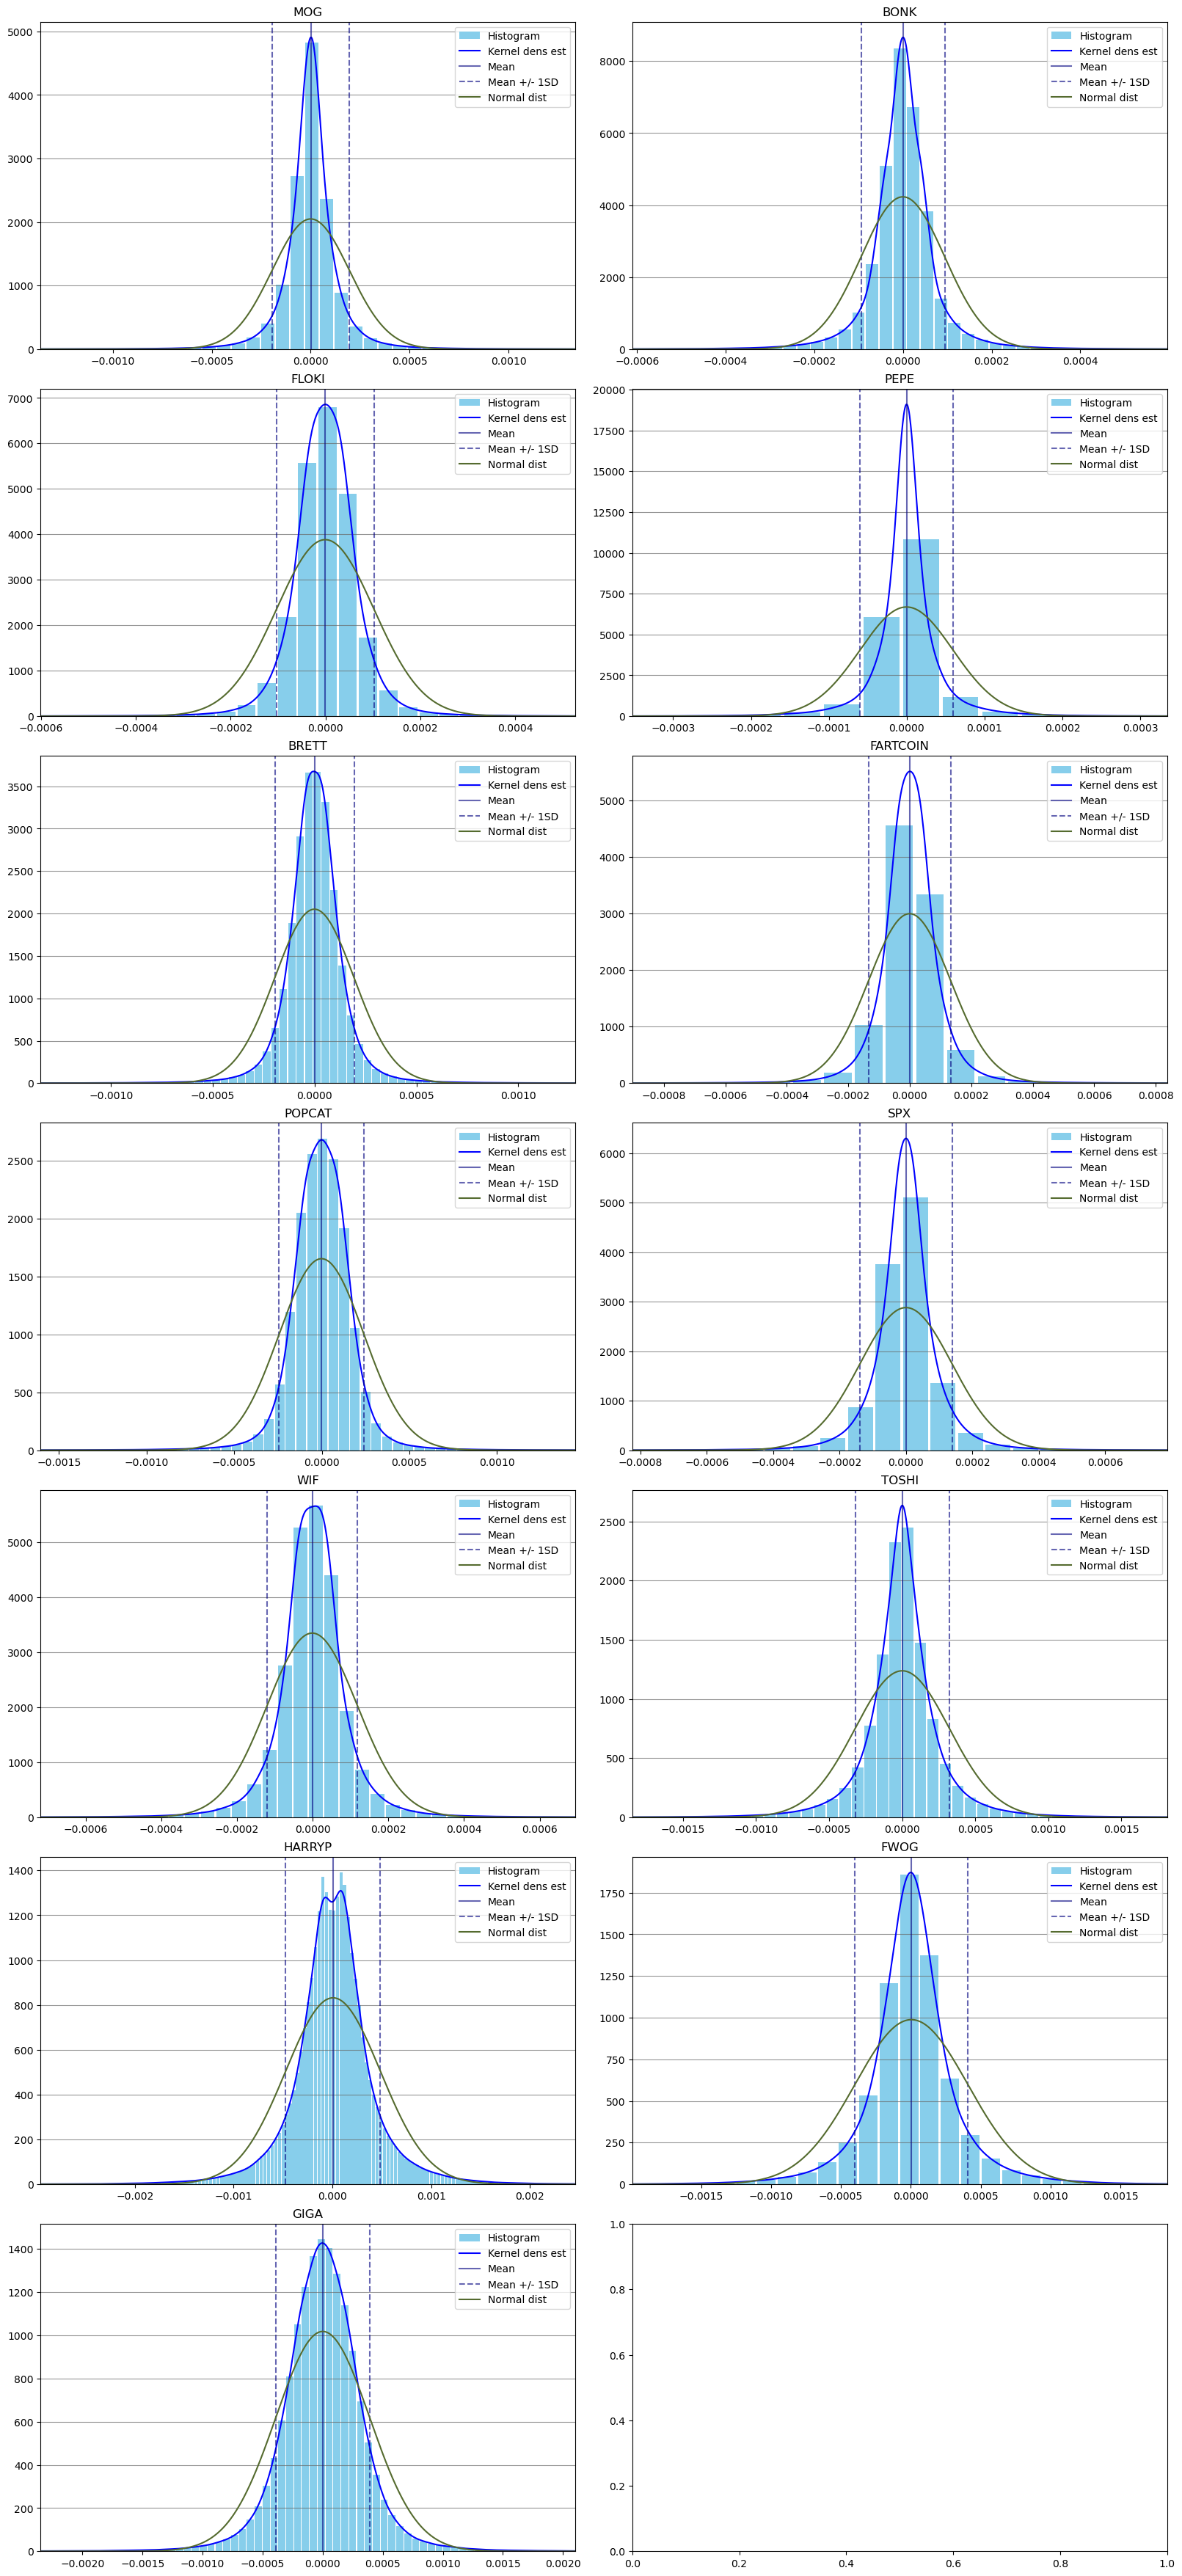

In [222]:
n_ro = int(np.ceil((len(memes_bin) + len(memes_byb)) / 2))
fig, ax = plt.subplots(n_ro, 2, figsize = (16, n_ro * 5), constrained_layout = True)

for i, m in enumerate(memes_bin):

    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    low_b, hig_b = lr_res.quantile(0.001), lr_res.quantile(0.999)
    xs = np.linspace(low_b, hig_b, 1000)
    kde = KernelDensity(kernel = "gaussian", bandwidth = lr_res.std() * 0.1).fit(pd.DataFrame(lr_res))
    log_dens = kde.score_samples(pd.DataFrame(xs))
    
    ax[i // 2, i % 2].hist(lr_res, bins = 1000, rwidth = 0.9, density = True, color = 'skyblue', label = "Histogram")
    ax[i // 2, i % 2].plot(xs, np.exp(log_dens), c = 'blue', label = "Kernel dens est")
    ax[i // 2, i % 2].axvline(x = lr_res.mean(), color = "navy", alpha = 0.6, label = "Mean")
    ax[i // 2, i % 2].axvline(x = lr_res.mean() + lr_res.std(), color = "navy", linestyle = "dashed", alpha = 0.6, label = "Mean +/- 1SD")
    ax[i // 2, i % 2].axvline(x = lr_res.mean() - lr_res.std(), color = "navy", linestyle = "dashed", alpha = 0.6)
    ax[i // 2, i % 2].plot(xs, norm.pdf(xs, lr_res.mean(), lr_res.std()), color = "darkolivegreen", label = "Normal dist")
    ax[i // 2, i % 2].set_xlim([low_b, hig_b])
    ax[i // 2, i % 2].set_title(m)
    ax[i // 2, i % 2].grid(axis = 'y', alpha = 0.7, color = 'dimgray')
    ax[i // 2, i % 2].legend()

for i, m in enumerate(memes_byb):
    
    j = i + len(memes_bin)
    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    low_b, hig_b = lr_res.quantile(0.001), lr_res.quantile(0.999)
    xs = np.linspace(low_b, hig_b, 1000)
    kde = KernelDensity(kernel = "gaussian", bandwidth = lr_res.std() * 0.1).fit(pd.DataFrame(lr_res))
    log_dens = kde.score_samples(pd.DataFrame(xs))
    
    ax[j // 2, j % 2].hist(lr_res, bins = 1000, rwidth = 0.9, density = True, color = 'skyblue', label = "Histogram")
    ax[j // 2, j % 2].plot(xs, np.exp(log_dens), c = 'blue', label = "Kernel dens est")
    ax[j // 2, j % 2].axvline(x = lr_res.mean(), color = "navy", alpha = 0.6, label = "Mean")
    ax[j // 2, j % 2].axvline(x = lr_res.mean() + lr_res.std(), color = "navy", linestyle = "dashed", alpha = 0.6, label = "Mean +/- 1SD")
    ax[j // 2, j % 2].axvline(x = lr_res.mean() - lr_res.std(), color = "navy", linestyle = "dashed", alpha = 0.6)
    ax[j // 2, j % 2].plot(xs, norm.pdf(xs, lr_res.mean(), lr_res.std()), color = "darkolivegreen", label = "Normal dist")
    ax[j // 2, j % 2].set_xlim([low_b, hig_b])
    ax[j // 2, j % 2].set_title(m)
    ax[j // 2, j % 2].grid(axis = 'y', alpha = 0.7, color = 'dimgray')
    ax[j // 2, j % 2].legend()
    
plt.show()

Jarque-Bera test -> 'Linear Regression models' section

Kolmogorov-Smirnov test

In [223]:
for m in memes_bin.keys():
    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    print(m, kstest(lr_res, 'norm', args = (lr_res.mean(), lr_res.std())).pvalue)
for m in memes_byb.keys():
    lr_res = globals()[m + '_imp_mod_cc_5'].resid
    print(m, kstest(lr_res, 'norm', args = (lr_res.mean(), lr_res.std())).pvalue)

MOG 0.0
BONK 0.0
FLOKI 0.0
PEPE 0.0
BRETT 0.0
FARTCOIN 0.0
POPCAT 0.0
SPX 0.0
WIF 0.0
TOSHI 0.0
HARRYP 0.0
FWOG 0.0
GIGA 0.0


#### Impact analysis

In [452]:
volus = [1, 500, 1000, 2500, 5000, 10000, 20000]

##### One-time - price impact only

Impact predictions for different order sizes (volumes) for average EWMA hourly realized variance and volume

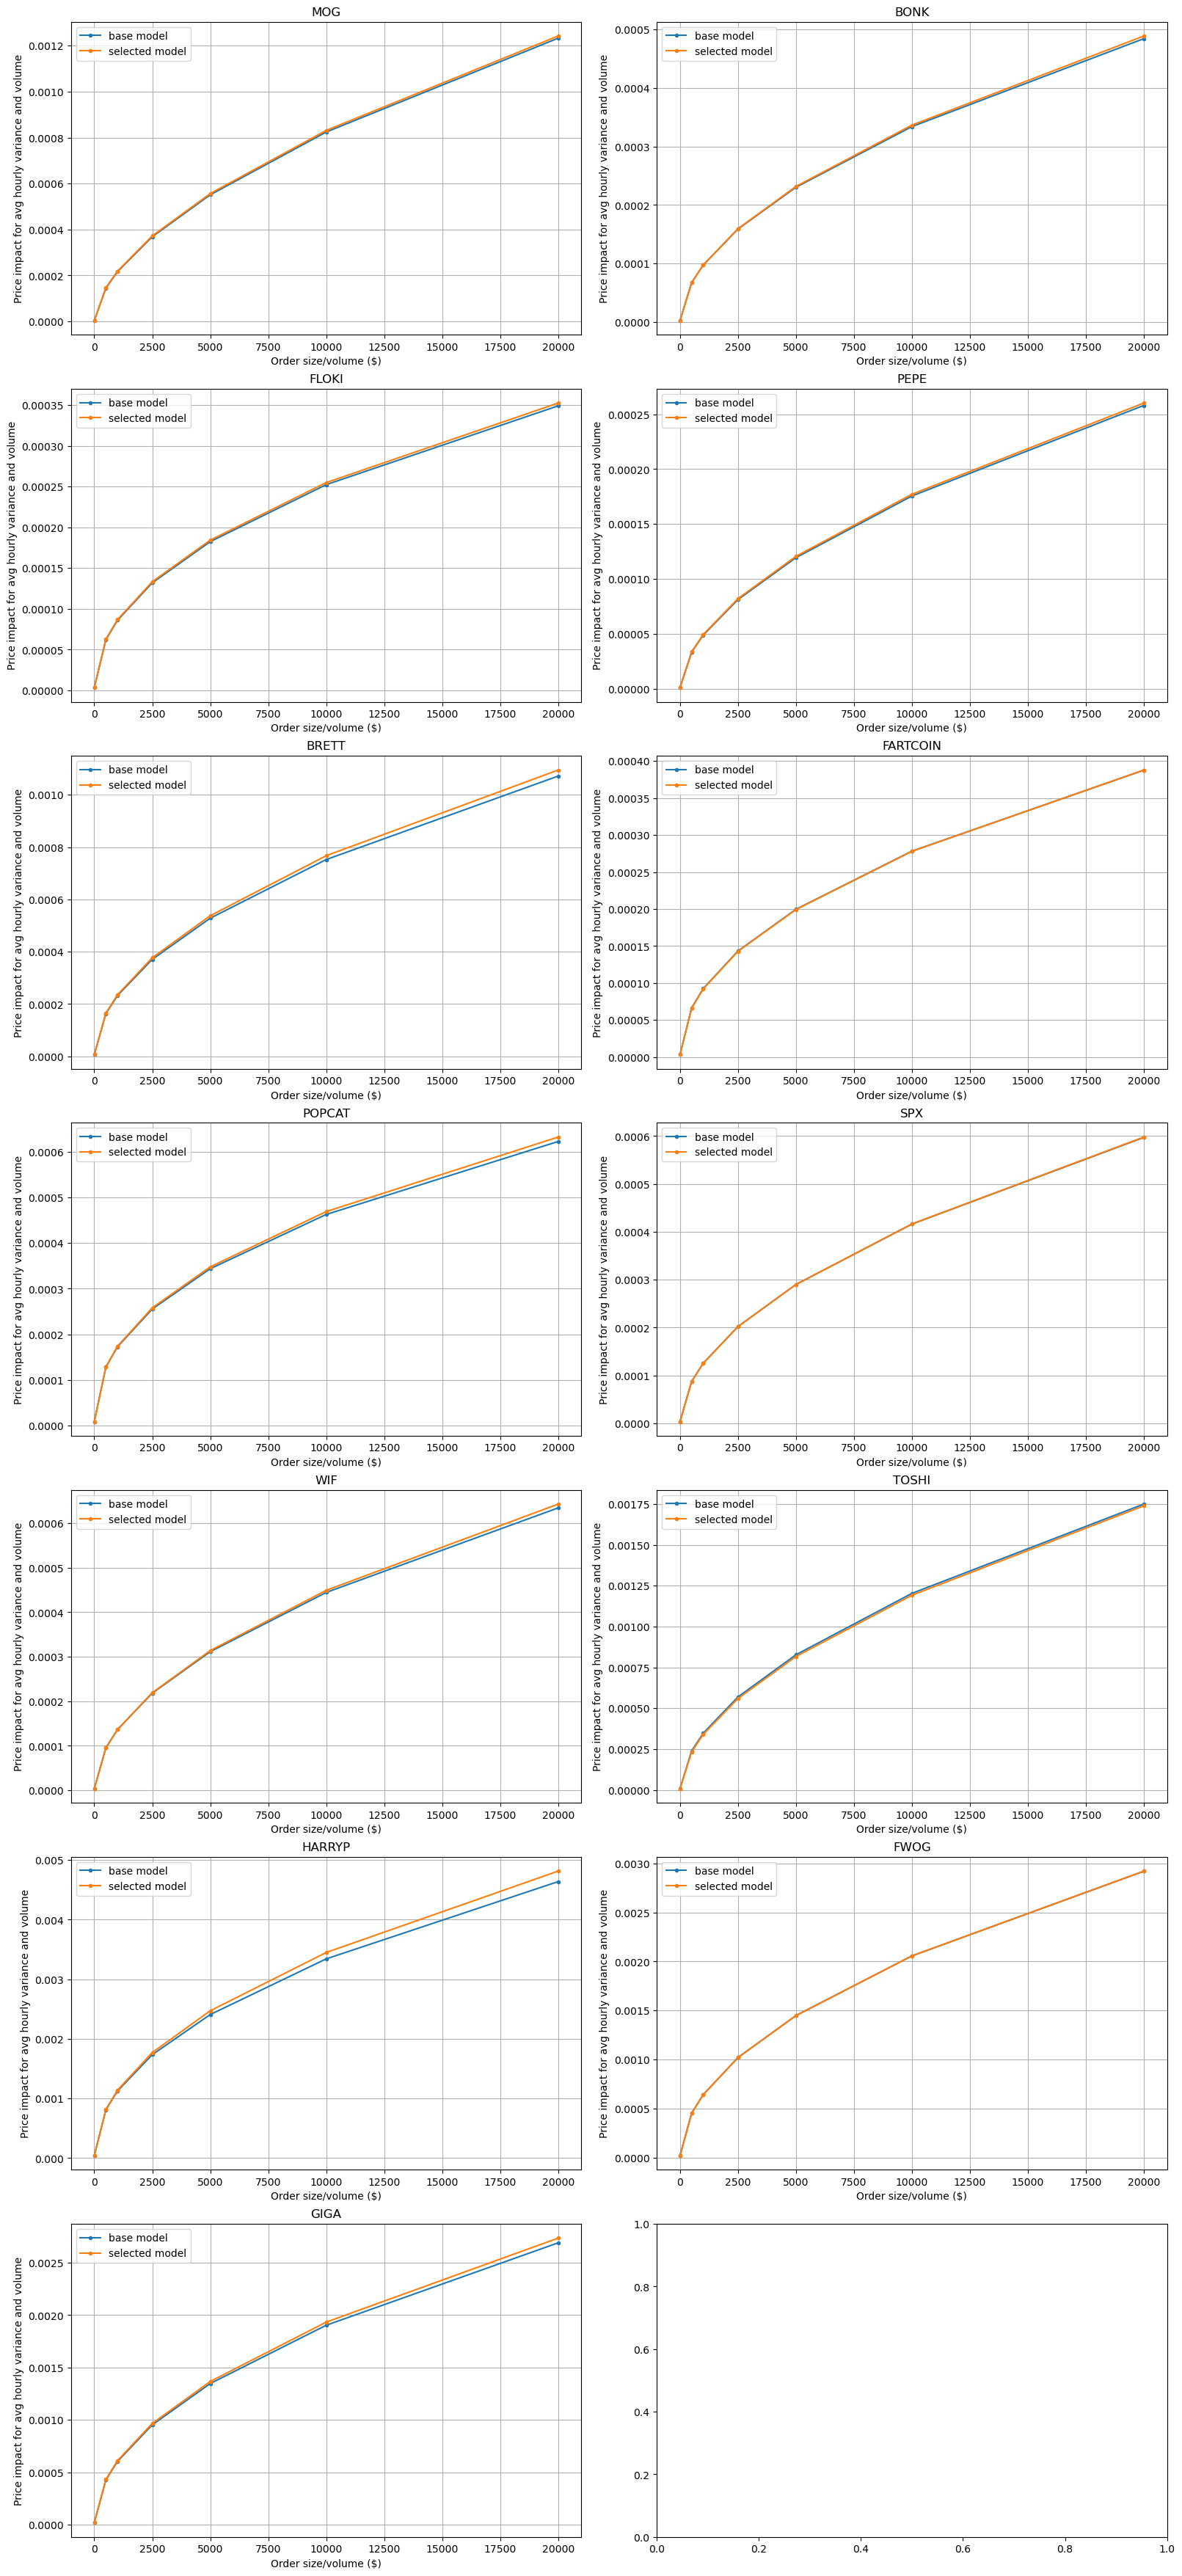

In [529]:
n_ro = int(np.ceil((len(memes_bin) + len(memes_byb)) / 2))
fig, ax = plt.subplots(n_ro, 2, figsize = (16, n_ro * 5), constrained_layout = True)

for i, m in enumerate(memes_bin):
    impas_1 = globals()[m + '_imp_mod_cc_1'].params.iloc[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var'].mean()) * (volus / globals()[m + '_ag_tr_df']['daily_volume'].mean()) ** volu_exp_1[m]
    impas_5 = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma'].mean()) * (volus / globals()[m + '_ag_tr_df']['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
    ax[i // 2, i % 2].plot(volus, impas_1, marker = '.', label = 'base model')
    ax[i // 2, i % 2].plot(volus, impas_5, marker = '.', label = 'selected model')
    ax[i // 2, i % 2].set_title(m)
    ax[i // 2, i % 2].set_xlabel('Order size/volume ($)')
    ax[i // 2, i % 2].set_ylabel('Price impact for avg hourly variance and volume')
    ax[i // 2, i % 2].grid()
    ax[i // 2, i % 2].legend()

for i, m in enumerate(memes_byb):
    j = i + len(memes_bin)
    impas_1 = globals()[m + '_imp_mod_cc_1'].params.iloc[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var'].mean()) * (volus / globals()[m + '_ag_tr_df']['daily_volume'].mean()) ** volu_exp_1[m]
    impas_5 = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma'].mean()) * (volus / globals()[m + '_ag_tr_df']['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
    ax[j // 2, j % 2].plot(volus, impas_1, marker = '.', label = 'base model')
    ax[j // 2, j % 2].plot(volus, impas_5, marker = '.', label = 'selected model')
    ax[j // 2, j % 2].set_title(m)
    ax[j // 2, j % 2].set_xlabel('Order size/volume ($)')
    ax[j // 2, j % 2].set_ylabel('Price impact for avg hourly variance and volume')
    ax[j // 2, j % 2].grid()
    ax[j // 2, j % 2].legend()

plt.show()

Impact distributions based on residuals for observations with selected values of explanatory variable (namely, in the proximity of values corresponding to selected order volumes for for average EWMA hourly realized variance and volume)

In [468]:
pcts = [1, 2, 3, 5, 10]
for m in memes_bin.keys():
    print(m)
    m_temp = globals()[m + '_ag_tr_df'][['impact', 'volume', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['x'] = np.sqrt(m_temp['real_var_h_ewma']) * (m_temp['volume'] / m_temp['hourly_volume_ewma']) ** volu_exp_5[m]
    for i in pcts:
        globals()['lens_' + str(i)] = list()
        for v in volus[1:]:
            low_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 - i / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
            hig_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 + i / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
            globals()['lens_' + str(i)].append(len(m_temp.loc[(m_temp['x'] > low_b) & (m_temp['x'] < hig_b)]))
        print(i, globals()['lens_' + str(i)])
for m in memes_byb.keys():
    print(m)
    m_temp = globals()[m + '_ag_tr_df'][['impact', 'volume', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['x'] = np.sqrt(m_temp['real_var_h_ewma']) * (m_temp['volume'] / m_temp['hourly_volume_ewma']) ** volu_exp_5[m]
    for i in pcts:
        globals()['lens_' + str(i)] = list()
        for v in volus[1:]:
            low_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 - i / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
            hig_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 + i / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
            globals()['lens_' + str(i)].append(len(m_temp.loc[(m_temp['x'] > low_b) & (m_temp['x'] < hig_b)]))
        print(i, globals()['lens_' + str(i)])

MOG
1 [13864, 11403, 4551, 1939, 798, 270]
2 [27734, 22593, 9003, 3940, 1570, 533]
3 [41530, 33891, 13507, 5922, 2386, 773]
5 [69087, 56165, 22346, 10010, 4020, 1327]
10 [139326, 112262, 45152, 20207, 8003, 2761]
BONK
1 [20222, 11131, 5603, 2716, 1138, 410]
2 [40520, 22156, 11452, 5395, 2294, 856]
3 [60863, 33227, 17042, 8053, 3447, 1302]
5 [101950, 55739, 28242, 13371, 5690, 2131]
10 [205320, 112366, 56362, 26921, 11323, 4196]
FLOKI
1 [13790, 15574, 13547, 7554, 3348, 1325]
2 [27609, 31225, 27055, 15180, 6765, 2628]
3 [41700, 46879, 40618, 22953, 10175, 4017]
5 [69842, 78592, 67842, 38288, 16870, 6804]
10 [140424, 156957, 135625, 75874, 33845, 13788]
PEPE
1 [47612, 34943, 16300, 8997, 3918, 1166]
2 [94280, 69487, 32597, 17973, 7782, 2311]
3 [140902, 104539, 49053, 27161, 11736, 3415]
5 [233589, 174165, 82138, 45308, 19349, 5632]
10 [464753, 350763, 165143, 91123, 38593, 11357]
BRETT
1 [8924, 6983, 3800, 1958, 758, 273]
2 [18240, 14068, 7646, 3755, 1562, 537]
3 [27306, 21148, 11417, 56

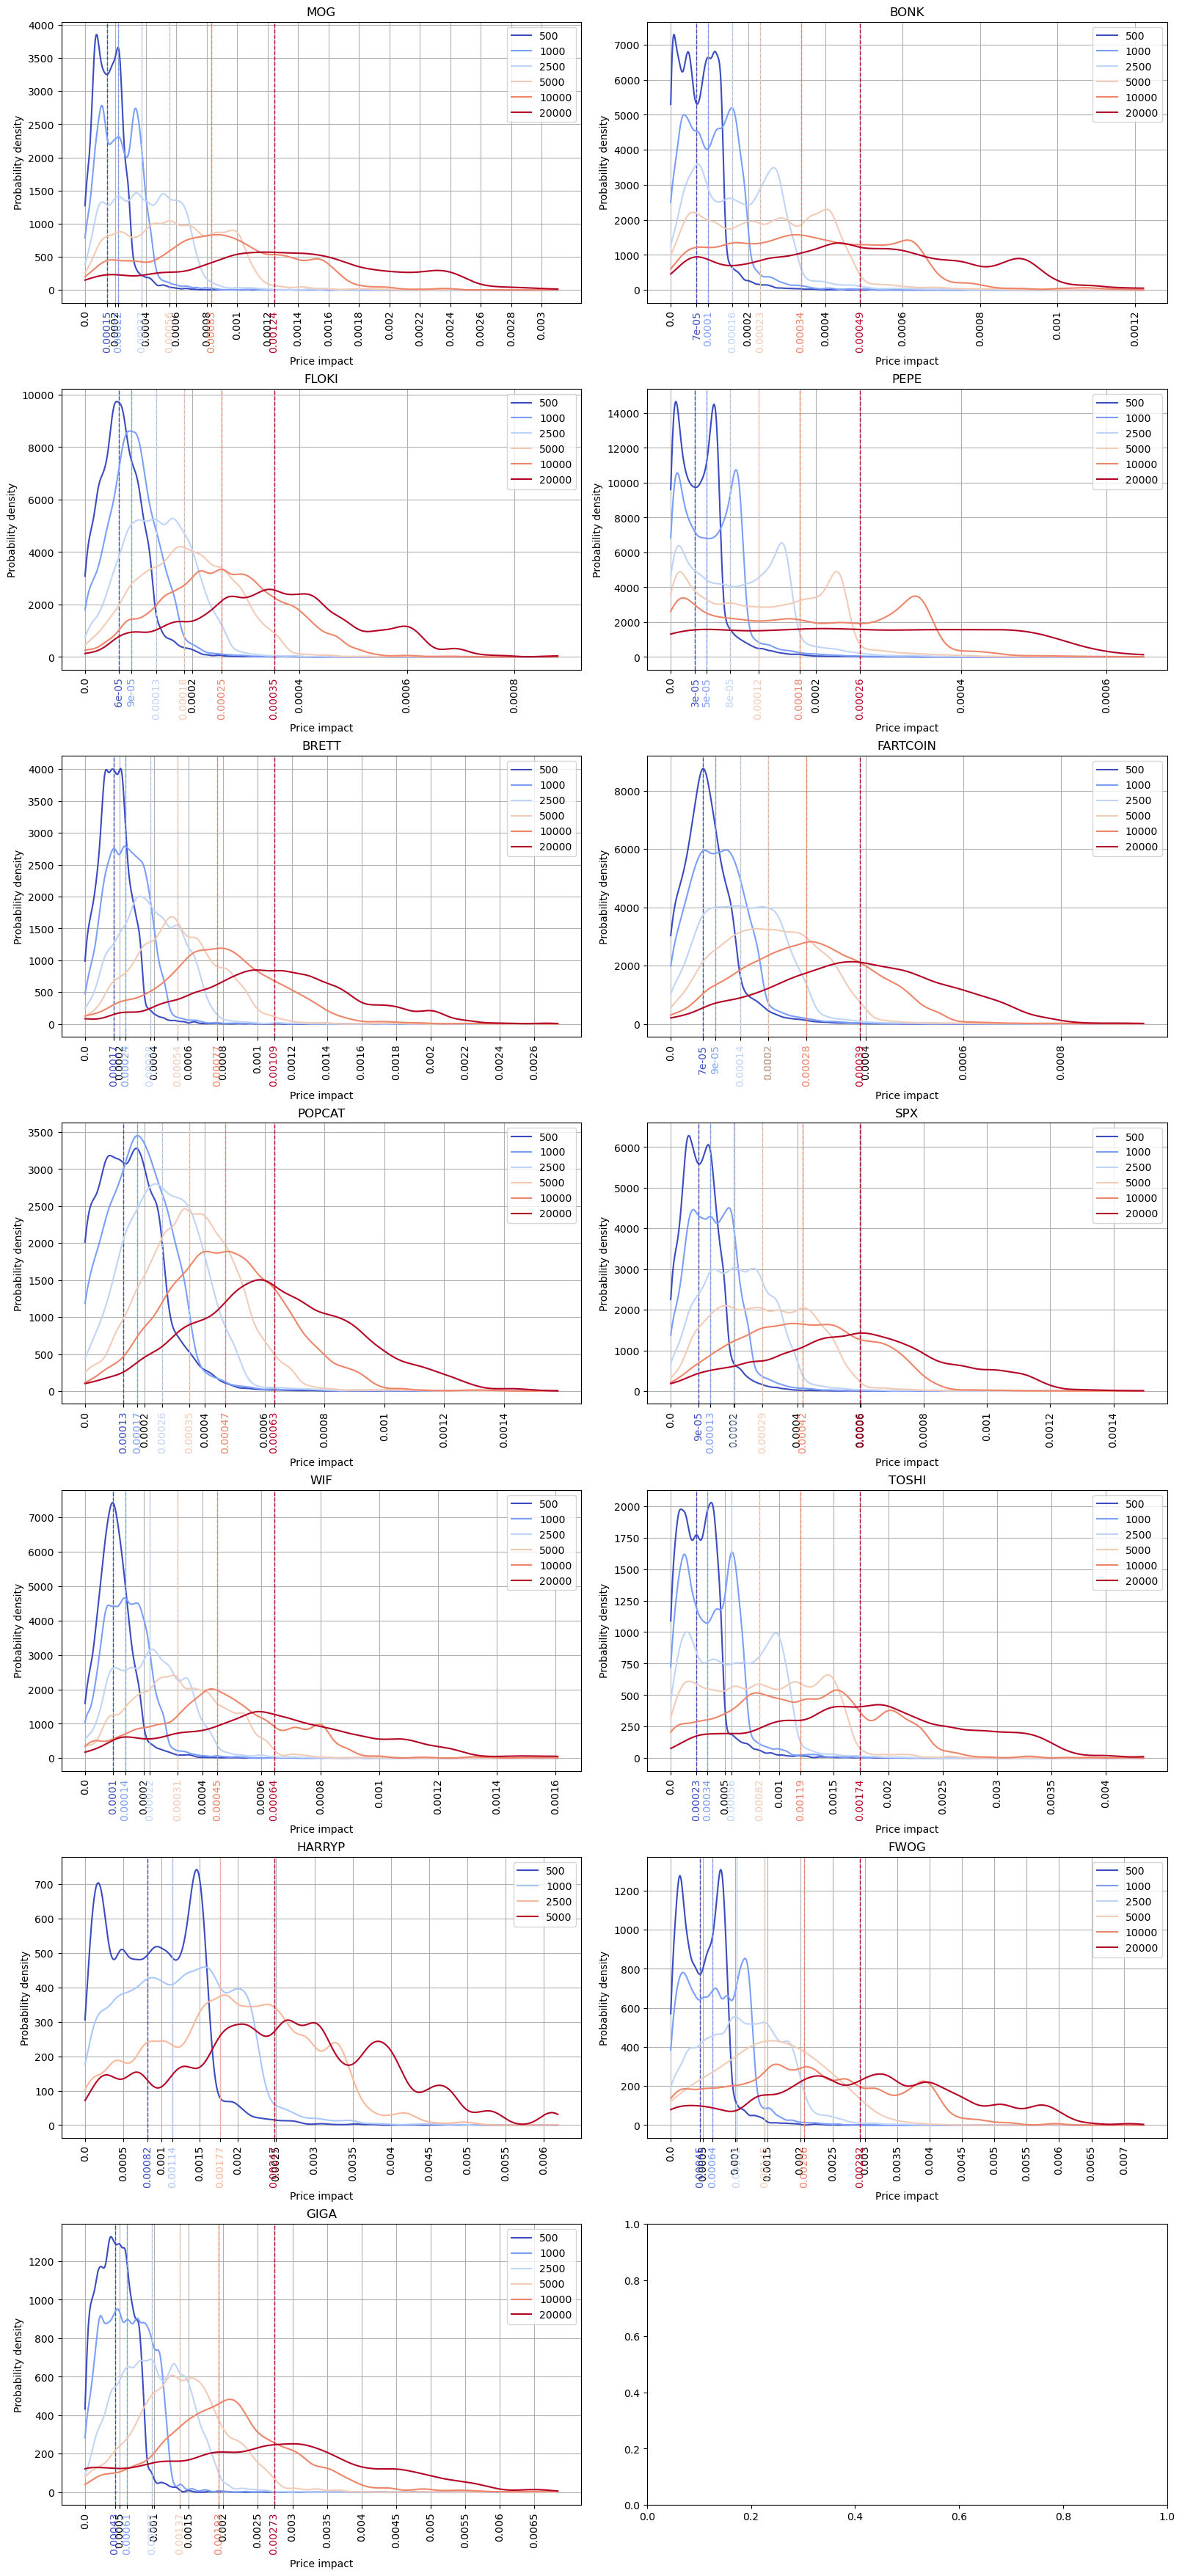

In [553]:
pcts = {'MOG': [1, 1, 1, 1, 2, 5], 'BONK': [1, 1, 1, 1, 1, 3], 'FLOKI': [1, 1, 1, 1, 1, 1], 'PEPE': [1, 1, 1, 1, 1, 1], 'BRETT': [1, 1, 1, 1, 2, 5],
        'FARTCOIN': [1, 1, 1, 1, 1, 1], 'POPCAT': [1, 1, 1, 1, 1, 1], 'SPX': [1, 1, 1, 1, 1, 1], 'WIF': [1, 1, 1, 1, 2, 5], 'TOSHI': [1, 1, 1, 1, 1, 3],
        'HARRYP': [5, 5, 10, 10], 'FWOG': [1, 1, 2, 3, 10, 10], 'GIGA': [1, 1, 2, 3, 10, 10]}

n_ro = int(np.ceil((len(memes_bin) + len(memes_byb)) / 2))
fig, ax = plt.subplots(n_ro, 2, figsize = (16, n_ro * 5), constrained_layout = True)

for i, m in enumerate(memes_bin):
    
    m_temp = globals()[m + '_ag_tr_df'][['impact', 'volume', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['x'] = np.sqrt(m_temp['real_var_h_ewma']) * (m_temp['volume'] / m_temp['hourly_volume_ewma']) ** volu_exp_5[m]
    m_temp['resid'] = globals()[m + '_imp_mod_cc_5'].resid
    impas_m = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * np.sqrt(m_temp['real_var_h_ewma'].mean()) * (volus[1:] / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
    imp_max = impas_m[-1] * 2.5
    
    for l, v in enumerate(volus[1:]):
        low_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 - pcts[m][l] / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
        hig_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 + pcts[m][l] / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
        imp_pred = impas_m[l]
        m_temp_v = m_temp.loc[(m_temp['x'] > low_b) & (m_temp['x'] < hig_b)]
        kde = KernelDensity(kernel = "gaussian", bandwidth = m_temp_v['resid'].std() * 0.1).fit(pd.DataFrame(imp_pred + m_temp_v['resid']))
        log_dens = kde.score_samples(pd.DataFrame({'resid': np.linspace(0, imp_max, 1000)}))
        ax[i // 2, i % 2].plot(np.linspace(0, imp_max, 1000), np.exp(log_dens), c = plt.get_cmap('coolwarm', len(volus[1:]))(l), label = v)
        ax[i // 2, i % 2].axvline(x = imp_pred, linestyle = '--', lw = 1, c = plt.get_cmap('coolwarm', len(volus[1:]))(l))
    
    ax[i // 2, i % 2].set_title(m)
    ax[i // 2, i % 2].set_xlabel('Price impact')
    ax[i // 2, i % 2].set_ylabel('Probability density')
    ticks = list(np.arange(0, imp_max, 0.0002)) + list(impas_m)
    ax[i // 2, i % 2].set_xticks(ticks, labels = [round(tic, 5) for tic in ticks], rotation = 90, ha = 'center')
    for l in range(len(impas_m)):
        ax[i // 2, i % 2].get_xticklabels()[l - len(impas_m)].set_color(plt.get_cmap('coolwarm', len(impas_m))(l))
    ax[i // 2, i % 2].grid()
    ax[i // 2, i % 2].legend()

for i, m in enumerate(memes_byb):

    j = i + len(memes_bin)
    m_temp = globals()[m + '_ag_tr_df'][['impact', 'volume', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['x'] = np.sqrt(m_temp['real_var_h_ewma']) * (m_temp['volume'] / m_temp['hourly_volume_ewma']) ** volu_exp_5[m]
    m_temp['resid'] = globals()[m + '_imp_mod_cc_5'].resid
    
    if m == 'HARRYP':
        volus1 = volus[1:-2]
    else:
        volus1 = volus[1:]
    
    impas_m = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * np.sqrt(m_temp['real_var_h_ewma'].mean()) * (volus1 / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
    imp_max = impas_m[-1] * 2.5
    
    for l, v in enumerate(volus1):
        low_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 - pcts[m][l] / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
        hig_b = np.sqrt(m_temp['real_var_h_ewma'].mean()) * ((1 + pcts[m][l] / 100) * v / m_temp['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
        imp_pred = impas_m[l]
        m_temp_v = m_temp.loc[(m_temp['x'] > low_b) & (m_temp['x'] < hig_b)]
        kde = KernelDensity(kernel = "gaussian", bandwidth = m_temp_v['resid'].std() * 0.1).fit(pd.DataFrame(imp_pred + m_temp_v['resid']))
        log_dens = kde.score_samples(pd.DataFrame({'resid': np.linspace(0, imp_max, 1000)}))
        ax[j // 2, j % 2].plot(np.linspace(0, imp_max, 1000), np.exp(log_dens), c = plt.get_cmap('coolwarm', len(volus1))(l), label = v)
        ax[j // 2, j % 2].axvline(x = imp_pred, linestyle = '--', lw = 1, c = plt.get_cmap('coolwarm', len(volus1))(l))
    
    ax[j // 2, j % 2].set_title(m)
    ax[j // 2, j % 2].set_xlabel('Price impact')
    ax[j // 2, j % 2].set_ylabel('Probability density')
    ticks = list(np.arange(0, imp_max, 0.0005)) + list(impas_m)
    ax[j // 2, j % 2].set_xticks(ticks, labels = [round(tic, 5) for tic in ticks], rotation = 90, ha = 'center')
    for l in range(len(impas_m)):
        ax[j // 2, j % 2].get_xticklabels()[l - len(impas_m)].set_color(plt.get_cmap('coolwarm', len(impas_m))(l))
    ax[j // 2, j % 2].grid()
    ax[j // 2, j % 2].legend()

plt.show()

##### In&out - all costs: 
###### fees + bid-ask spread + impact + funding (avg per hour for long with small index price deviation)

Average bid-ask spread, average EWMA hourly realized variance and volume

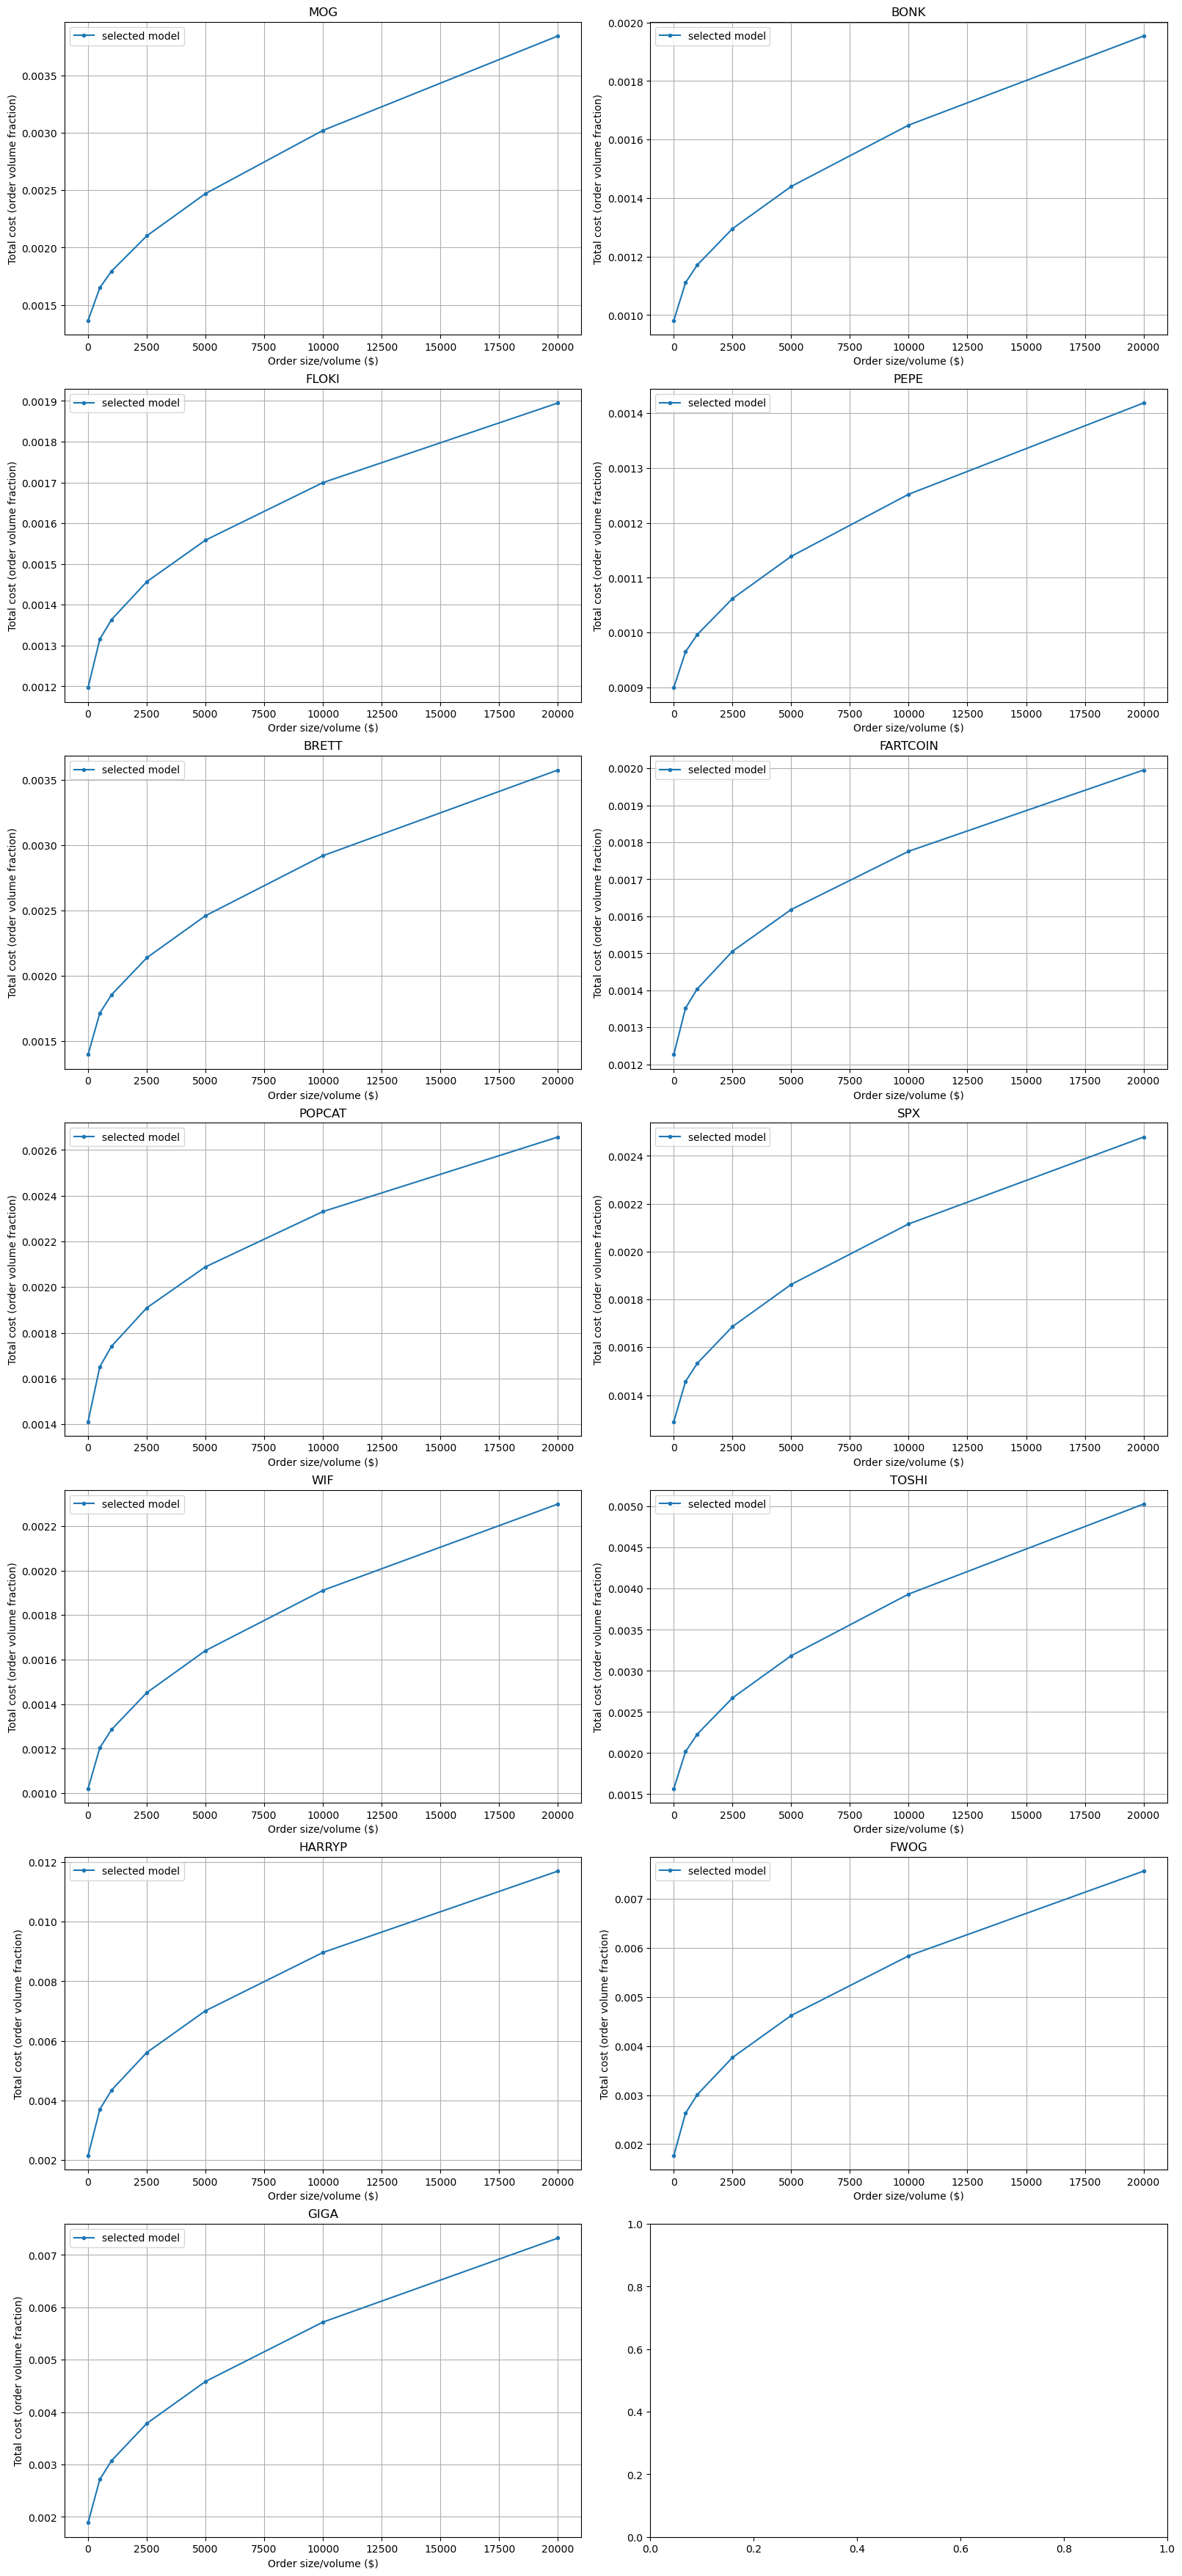

In [551]:
n_ro = int(np.ceil((len(memes_bin) + len(memes_byb)) / 2))
fig, ax = plt.subplots(n_ro, 2, figsize = (16, n_ro * 5), constrained_layout = True)

for i, m in enumerate(memes_bin):
    impas_5 = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma'].mean()) * (volus / globals()[m + '_ag_tr_df']['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
    ax[i // 2, i % 2].plot(volus, 2 * (fees_bin[m] + (df_bas / df[1:])[m].mean() / 2 + impas_5 + 0.0001 / 8), marker = '.', label = 'selected model')
    ax[i // 2, i % 2].set_title(m)
    ax[i // 2, i % 2].set_xlabel('Order size/volume ($)')
    ax[i // 2, i % 2].set_ylabel('Total cost (order volume fraction)')
    ax[i // 2, i % 2].grid()
    ax[i // 2, i % 2].legend()

for i, m in enumerate(memes_byb):
    j = i + len(memes_bin)
    impas_5 = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma'].mean()) * (volus / globals()[m + '_ag_tr_df']['hourly_volume_ewma'].mean()) ** volu_exp_5[m]
    ax[j // 2, j % 2].plot(volus, 2 * (fees_byb[m] + (df_bas / df[1:])[m].mean() / 2 + impas_5 + 0.0001 / 8), marker = '.', label = 'selected model')
    ax[j // 2, j % 2].set_title(m)
    ax[j // 2, j % 2].set_xlabel('Order size/volume ($)')
    ax[j // 2, j % 2].set_ylabel('Total cost (order volume fraction)')
    ax[j // 2, j % 2].grid()
    ax[j // 2, j % 2].legend()

plt.show()

Benign, neutral and adverse scenarios - corresponding to 1st, 2nd and 3rd quartile of the order volume multiplier in the explanatory variable, and average bid-ask spread for trades for which the multiplier is in the proximity of these quartiles

In [119]:
for m in memes_bin.keys():
    m_temp = globals()[m + '_ag_tr_df'][['hour', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['multi'] = np.sqrt(m_temp['real_var_h_ewma']) / m_temp['hourly_volume_ewma'] ** volu_exp_5[m]
    m_temp = m_temp.merge((df_bas / df[1:])[[m]], how = "left", left_on = 'hour', right_index = True)
    mul_b, mul_n, mul_a = m_temp['multi'].quantile([0.25, 0.5, 0.75])
    bas_b, bas_n, bas_a = [m_temp.loc[abs(m_temp['multi'] / mul - 1) < 0.01][m].mean() for mul in [mul_b, mul_n, mul_a]]
    print(m, bas_b, bas_n, bas_a)
for m in memes_byb.keys():
    m_temp = globals()[m + '_ag_tr_df'][['hour', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['multi'] = np.sqrt(m_temp['real_var_h_ewma']) / m_temp['hourly_volume_ewma'] ** volu_exp_5[m]
    m_temp = m_temp.merge((df_bas / df[1:])[[m]], how = "left", left_on = 'hour', right_index = True)
    mul_b, mul_n, mul_a = m_temp['multi'].quantile([0.25, 0.5, 0.75])
    bas_b, bas_n, bas_a = [m_temp.loc[abs(m_temp['multi'] / mul - 1) < 0.01][m].mean() for mul in [mul_b, mul_n, mul_a]]
    print(m, bas_b, bas_n, bas_a)

MOG 0.00026357482979811464 0.00027796843184720873 0.00030565890679020525
BONK 0.00010886648967526629 0.00013574579646260165 0.00016869304261747135
FLOKI 0.0001228320639688137 0.0001433534689220558 0.00016771280918442545
PEPE 5.75402013185416e-05 6.402753121059322e-05 6.68637015462935e-05
BRETT 0.0003073818335167501 0.00031156059468243546 0.00036319449475798215
FARTCOIN 0.00012124168917666295 0.00014259813015392097 0.00025704136976109913
POPCAT 0.0002726942448965399 0.0003214937854983429 0.0004116890898736248
SPX 0.00013011207436072758 0.0001277084584811044 0.0002696425241719489
WIF 0.0001580245800586425 0.00017407838134446396 0.0002009595911930406
TOSHI 0.00037110561146417106 0.0004339120914250948 0.00046410668580028325
HARRYP 0.0005192943470855229 0.0008319101446257599 0.0008996691181799294
FWOG 0.0005324938976103462 0.0005604007290933806 0.000670606360675816
GIGA 0.0006119568753542689 0.000690996729075337 0.0007889608251686992


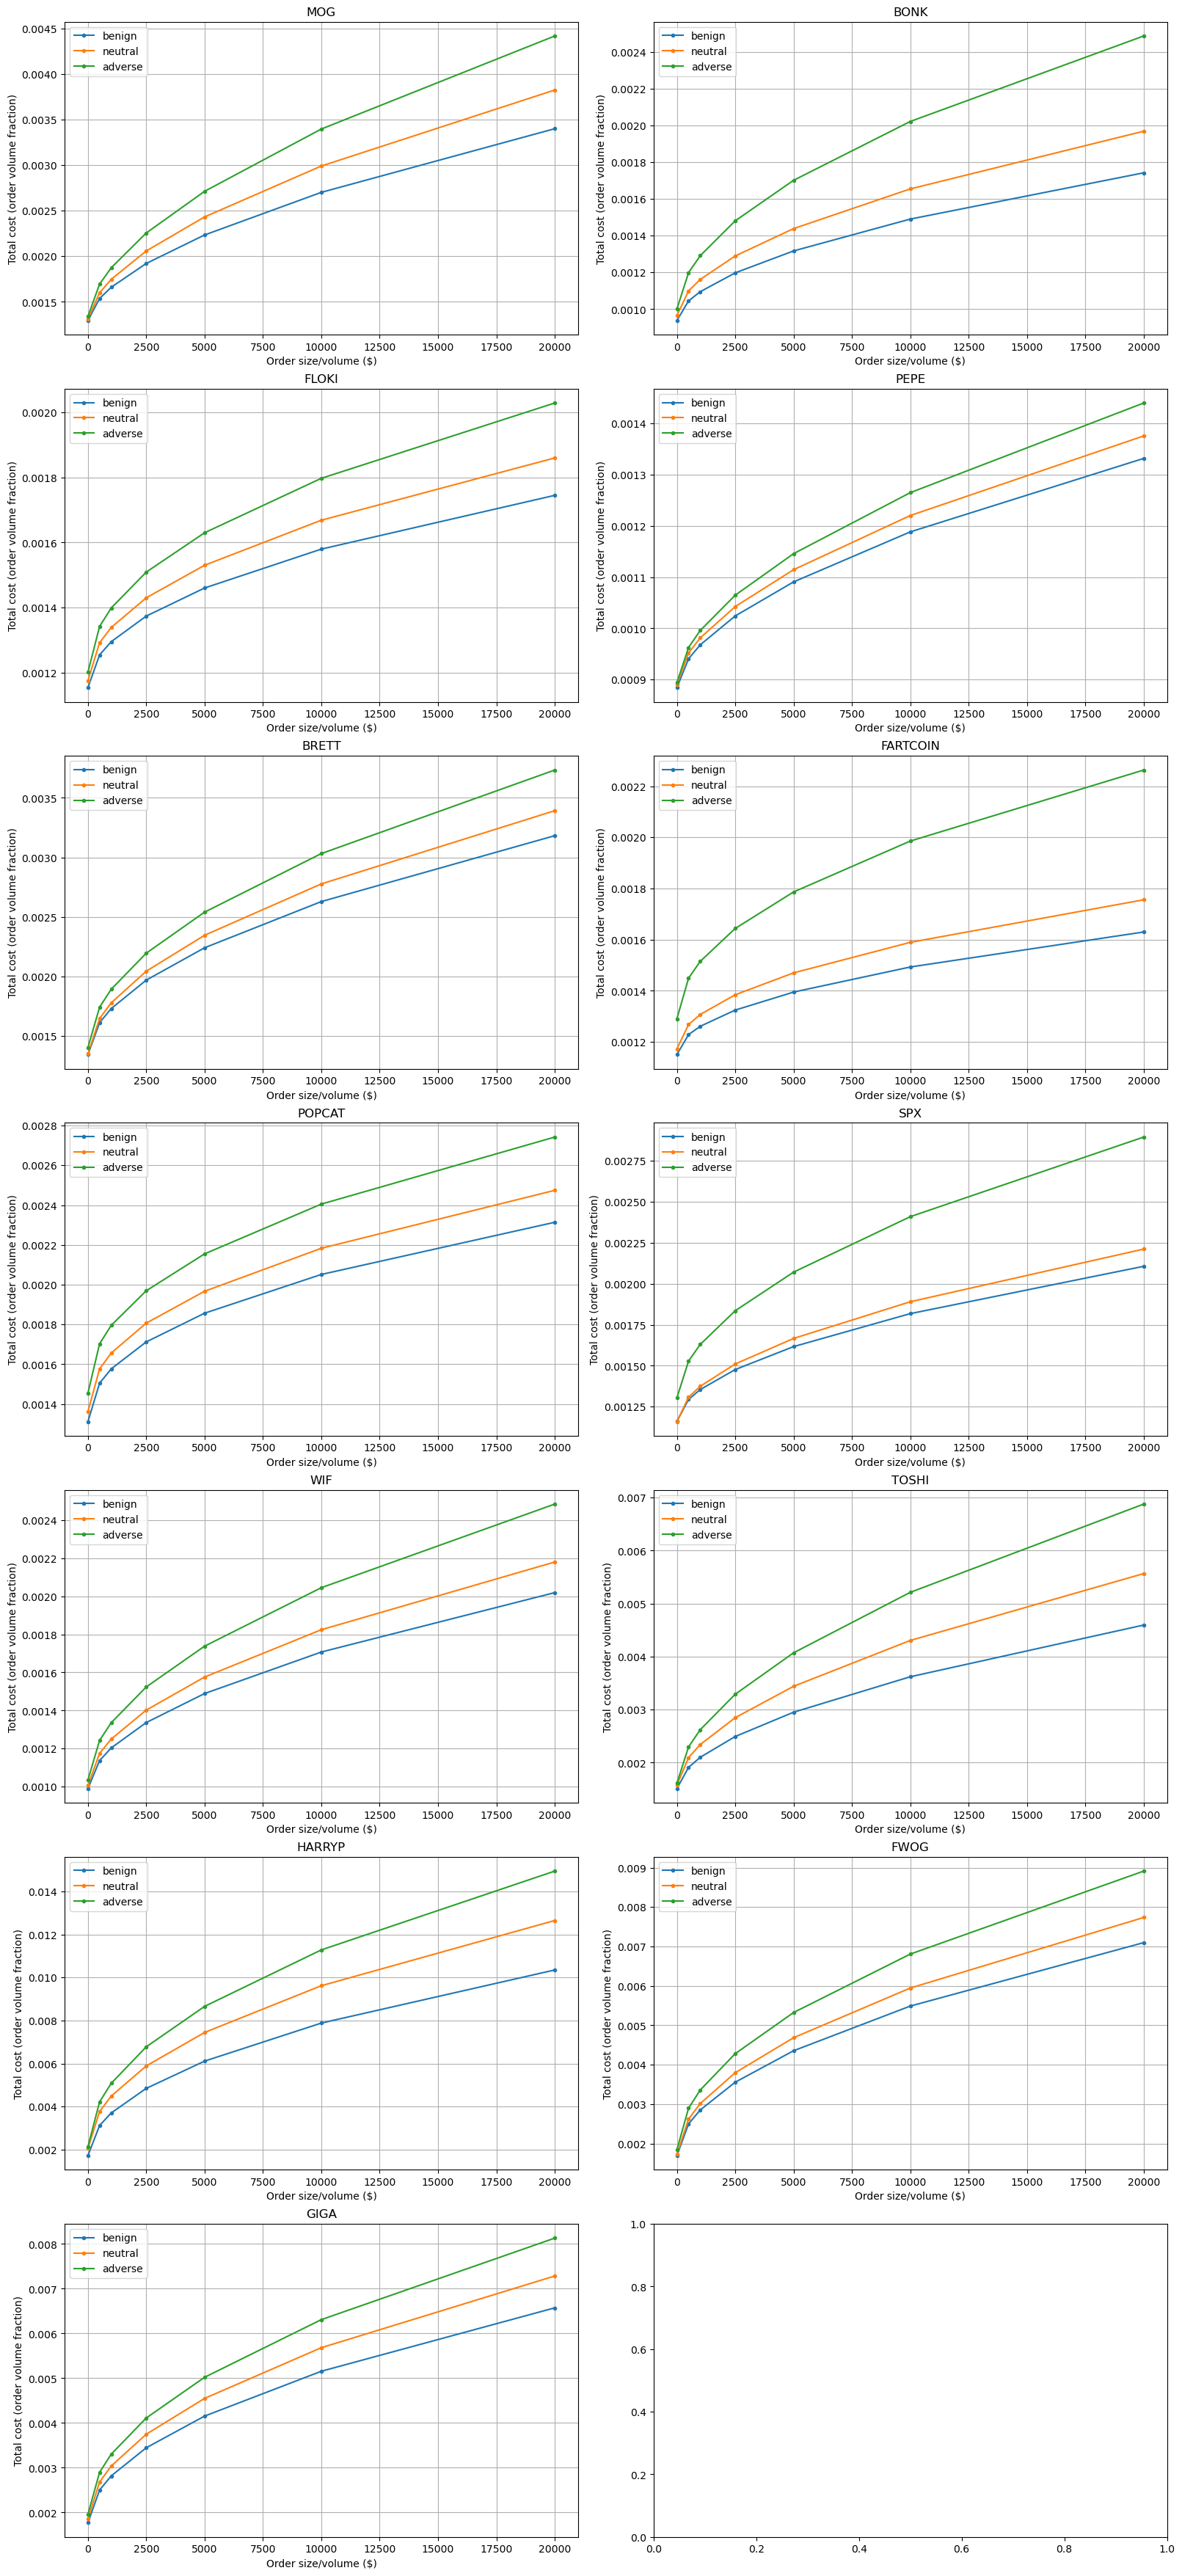

In [122]:
n_ro = int(np.ceil((len(memes_bin) + len(memes_byb)) / 2))
fig, ax = plt.subplots(n_ro, 2, figsize = (16, n_ro * 5), constrained_layout = True)

for i, m in enumerate(memes_bin):
    
    m_temp = globals()[m + '_ag_tr_df'][['hour', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['multi'] = np.sqrt(m_temp['real_var_h_ewma']) / m_temp['hourly_volume_ewma'] ** volu_exp_5[m]
    m_temp = m_temp.merge((df_bas / df[1:])[[m]], how = "left", left_on = 'hour', right_index = True)
    mul_b, mul_n, mul_a = m_temp['multi'].quantile([0.25, 0.5, 0.75])
    bas_b, bas_n, bas_a = [m_temp.loc[abs(m_temp['multi'] / mul - 1) < 0.01][m].mean() for mul in [mul_b, mul_n, mul_a]]

    for sce, mul, bas in zip(['benign', 'neutral', 'adverse'], [mul_b, mul_n, mul_a], [bas_b, bas_n, bas_a]):
        impas_sce = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * mul * volus ** volu_exp_5[m]
        ax[i // 2, i % 2].plot(volus, 2 * (fees_bin[m] + bas / 2 + impas_sce + 0.0001 / 8), marker = '.', label = sce)
    
    ax[i // 2, i % 2].set_title(m)
    ax[i // 2, i % 2].set_xlabel('Order size/volume ($)')
    ax[i // 2, i % 2].set_ylabel('Total cost (order volume fraction)')
    ax[i // 2, i % 2].grid()
    ax[i // 2, i % 2].legend()

for i, m in enumerate(memes_byb):
    
    j = i + len(memes_bin)
    m_temp = globals()[m + '_ag_tr_df'][['hour', 'real_var_h_ewma', 'hourly_volume_ewma']].copy()
    m_temp['multi'] = np.sqrt(m_temp['real_var_h_ewma']) / m_temp['hourly_volume_ewma'] ** volu_exp_5[m]
    m_temp = m_temp.merge((df_bas / df[1:])[[m]], how = "left", left_on = 'hour', right_index = True)
    mul_b, mul_n, mul_a = m_temp['multi'].quantile([0.25, 0.5, 0.75])
    bas_b, bas_n, bas_a = [m_temp.loc[abs(m_temp['multi'] / mul - 1) < 0.01][m].mean() for mul in [mul_b, mul_n, mul_a]]

    for sce, mul, bas in zip(['benign', 'neutral', 'adverse'], [mul_b, mul_n, mul_a], [bas_b, bas_n, bas_a]):
        impas_sce = globals()[m + '_imp_mod_cc_5'].params.iloc[0] * mul * volus ** volu_exp_5[m]
        ax[j // 2, j % 2].plot(volus, 2 * (fees_byb[m] + bas / 2 + impas_sce + 0.0001 / 8), marker = '.', label = sce)
    
    ax[j // 2, j % 2].set_title(m)
    ax[j // 2, j % 2].set_xlabel('Order size/volume ($)')
    ax[j // 2, j % 2].set_ylabel('Total cost (order volume fraction)')
    ax[j // 2, j % 2].grid()
    ax[j // 2, j % 2].legend()

plt.show()

Costs over time

In [531]:
imp_real_full = pd.DataFrame()
for m in memes_bin.keys():
    m_h_vol_df = globals()['df_' + m + '_bin'][['time', 'quote_volume']].rename(columns = {'time': 'hour', 'quote_volume': 'hourly_volume'})
    m_h_vol_df['hourly_volume_ewma'] = m_h_vol_df['hourly_volume'].ewm(alpha = 0.1).mean()
    m_h_rv_df = globals()['df_' + m + '_bin_min'][['hour', 'real_var']].rename(columns = {'real_var': 'real_var_h'}).groupby('hour', as_index = False).sum()
    m_h_rv_df['real_var_h_ewma'] = m_h_rv_df['real_var_h'].ewm(alpha = 0.1).mean()
    imp_real_full[m] = globals()[m + '_imp_mod_cc_fin'].params.iloc[0] * np.sqrt(m_h_rv_df['real_var_h_ewma']) / m_h_vol_df['hourly_volume_ewma'] ** volu_exp_fin[m]
for m in memes_byb.keys():
    m_h_vol_df = globals()['df_' + m + '_byb'].reset_index()[['time', 'foreignNotional']].rename(columns = {'time': 'hour', 'foreignNotional': 'hourly_volume'})
    m_h_vol_df['hourly_volume_ewma'] = m_h_vol_df['hourly_volume'].ewm(alpha = 0.1).mean()
    m_h_rv_df = globals()['df_' + m + '_byb_min'][['hour', 'real_var']].rename(columns = {'real_var': 'real_var_h'}).groupby('hour', as_index = False).sum()
    m_h_rv_df['real_var_h_ewma'] = m_h_rv_df['real_var_h'].ewm(alpha = 0.1).mean()
    imp_real_full[m] = globals()[m + '_imp_mod_cc_fin'].params.iloc[0] * np.sqrt(m_h_rv_df['real_var_h_ewma']) / m_h_vol_df['hourly_volume_ewma'] ** volu_exp_fin[m]
imp_real_full.index = globals()['df_' + m + '_byb'].index
imp_real_full = imp_real_full[memes][1:]

### Market Impact Model for Weights Optimization

#### Model development

##### No observation weighting

In [61]:
# hourly ewma (lag) 0.1
for m in memes_bin.keys():
    globals()[m + '_imp_mod_wo'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma_lag']) * globals()[m + '_ag_tr_df']['i'] * globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma_lag']).fit()
    print(m)
    print(globals()[m + '_imp_mod_wo'].summary())
    print()

MOG
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.369
Model:                            OLS   Adj. R-squared (uncentered):              0.369
Method:                 Least Squares   F-statistic:                          1.690e+06
Date:                Sat, 04 Apr 2026   Prob (F-statistic):                        0.00
Time:                        20:37:48   Log-Likelihood:                      2.0090e+07
No. Observations:             2893092   AIC:                                 -4.018e+07
Df Residuals:                 2893091   BIC:                                 -4.018e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [62]:
# hourly ewma (lag) 0.1
for m in memes_byb.keys():
    globals()[m + '_imp_mod_wo'] = sm.OLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma_lag']) * globals()[m + '_ag_tr_df']['i'] * globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma_lag']).fit()
    print(m)
    print(globals()[m + '_imp_mod_wo'].summary())
    print()

TOSHI
                                 OLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.302
Model:                            OLS   Adj. R-squared (uncentered):              0.302
Method:                 Least Squares   F-statistic:                          1.364e+06
Date:                Sat, 04 Apr 2026   Prob (F-statistic):                        0.00
Time:                        20:37:59   Log-Likelihood:                      2.0162e+07
No. Observations:             3154306   AIC:                                 -4.032e+07
Df Residuals:                 3154305   BIC:                                 -4.032e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

##### Observation weighting

In [41]:
volus = [1, 500, 1000, 2500, 5000, 10000, 20000]
w_cens = [0.00015, 0.0002, 0.00025, 0.0003, 0.0004]
w_scas = [0.00025, 0.0003, 0.0004, 0.0005, 0.0006]
colors = ['rosybrown', 'lightcoral', 'indianred', 'brown', 'maroon']

In [42]:
w_c_s_zip = [(c, s) for c, s in zip(w_cens, w_scas)]
memes_w_c_s = {'MOG': w_c_s_zip[2], 'BONK': w_c_s_zip[3], 'FLOKI': w_c_s_zip[3], 'PEPE': w_c_s_zip[4], 'BRETT': w_c_s_zip[2],
               'FARTCOIN': w_c_s_zip[2], 'POPCAT': w_c_s_zip[1], 'SPX': w_c_s_zip[2], 'WIF': w_c_s_zip[2], 'TOSHI': w_c_s_zip[0],
               'HARRYP': w_c_s_zip[1], 'FWOG': w_c_s_zip[1], 'GIGA': w_c_s_zip[1]}

In [43]:
for m in memes_bin.keys():
    c, s = memes_w_c_s[m]
    w = np.exp(-0.5 * ((abs(globals()[m + '_imp_mod_cc_5'].predict()) - c) ** 2) / (s ** 2))
    globals()[m + '_imp_mod_wo_w'] = sm.WLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma_lag']) * globals()[m + '_ag_tr_df']['i'] * globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma_lag'], weights = w).fit()
    print(m)
    print(globals()[m + '_imp_mod_wo_w'].summary())
    print()
for m in memes_byb.keys():
    c, s = memes_w_c_s[m]
    w = np.exp(-0.5 * ((abs(globals()[m + '_imp_mod_cc_5'].predict()) - c) ** 2) / (s ** 2))
    globals()[m + '_imp_mod_wo_w'] = sm.WLS(globals()[m + '_ag_tr_df']['impact'], np.sqrt(globals()[m + '_ag_tr_df']['real_var_h_ewma_lag']) * globals()[m + '_ag_tr_df']['i'] * globals()[m + '_ag_tr_df']['volume'] / globals()[m + '_ag_tr_df']['hourly_volume_ewma_lag'], weights = w).fit()
    print(m)
    print(globals()[m + '_imp_mod_wo_w'].summary())
    print()

MOG
                                 WLS Regression Results                                
Dep. Variable:                 impact   R-squared (uncentered):                   0.396
Model:                            WLS   Adj. R-squared (uncentered):              0.396
Method:                 Least Squares   F-statistic:                          1.899e+06
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                        0.00
Time:                        14:15:12   Log-Likelihood:                      2.0730e+07
No. Observations:             2893092   AIC:                                 -4.146e+07
Df Residuals:                 2893091   BIC:                                 -4.146e+07
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

### Final Models

In [99]:
for m in memes_bin.keys():
    globals()[m + '_imp_mod_cc_fin'] = globals()[m + '_imp_mod_cc_5']
    globals()[m + '_imp_mod_wo_fin'] = globals()[m + '_imp_mod_wo_w']
for m in memes_byb.keys():
    globals()[m + '_imp_mod_cc_fin'] = globals()[m + '_imp_mod_cc_5']
    globals()[m + '_imp_mod_wo_fin'] = globals()[m + '_imp_mod_wo_w']
volu_exp_fin = volu_exp_5

In [100]:
imp_mod_params = pd.DataFrame(index = memes, columns = ['wo_coef', 'cc_coef', 'cc_exp'])
for m in memes:
    imp_mod_params.at[m, 'wo_coef'] = globals()[m + '_imp_mod_wo_fin'].params.iloc[0]
    imp_mod_params.at[m, 'cc_coef'] = globals()[m + '_imp_mod_cc_fin'].params.iloc[0]
    imp_mod_params.at[m, 'cc_exp'] = volu_exp_fin[m]

In [103]:
imp_mod_params.to_csv('intermediate_output/imp_mod_params.csv', index = True)

In [27]:
imp_mod_params = pd.read_csv('intermediate_output/imp_mod_params.csv').set_index('Unnamed: 0')